# Baseline Model Evaluation
This notebook evaluates the pre-trained `SamLowe/roberta-base-go_emotions` model to establish a strong baseline for our project. We can later use these results to compare against our own custom-trained models.

In [1]:
"""import warnings
warnings.filterwarnings('ignore')

#%load_ext autoreload
#%autoreload 2

import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from dotenv import load_dotenv
from huggingface_hub import login
import torch
from sklearn.model_selection import train_test_split
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import nltk
from itertools import combinations
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Add the source folder to sys.path so we can import our modules
source_code_path = os.path.abspath('../source')
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from baseline_roberta import *
from general_preprocessing import *
from visualizations import *
from modeling import *"""

"import warnings\nwarnings.filterwarnings('ignore')\n\n#%load_ext autoreload\n#%autoreload 2\n\nimport sys\nimport os\nimport pandas as pd\nfrom sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer\nfrom dotenv import load_dotenv\nfrom huggingface_hub import login\nimport torch\nfrom sklearn.model_selection import train_test_split\nimport numpy as np\nfrom vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer\nfrom torch.utils.data import Dataset\nfrom transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments\nimport nltk\nfrom itertools import combinations\nimport pandas as pd\nimport numpy as np\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nfrom sklearn.model_selection import train_test_split\n\n# Add the source folder to sys.path so we can import our modules\nsource_code_path = os.path.abspath('../source')\nif source_code_path not in sys.path:\n    sys.path.append(source_code_path)\n\nfrom my_utils impor

USING GOOGLE COLAB

In [2]:
!pip install emoji
!pip install unidecode
!pip install gensim
!pip install Levenshtein
!pip install jellyfish
!pip install vaderSentiment
!pip install plotly kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 89.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.1 MB/s eta 0:00:00


In [3]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from dotenv import load_dotenv
from huggingface_hub import login
import torch
from sklearn.model_selection import train_test_split
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import nltk
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from torch.utils.data import Dataset
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss

In [4]:
drive.mount('/content/drive')

# Copy your entire project to /content/ailab if not already there
if not os.path.exists('/content/ailab'):
    print("Copying files from Drive...")
    !cp -r "/content/drive/MyDrive/ailab" /content/
    print("Files copied!")
else:
    print("Files already exist in /content/ailab")

# Go to the ailab directory (this becomes your project root)
os.chdir('/content/ailab')
print(f"📁 Current directory: {os.getcwd()}")

# Create symlinks to make relative paths work with your existing code
!ln -sf /content/ailab/data ./data
!ln -sf /content/ailab/source ./source
!ln -sf /content/ailab/notebooks ./notebooks

# Create necessary directories
!mkdir -p /content/results
!mkdir -p /content/wordclouds

# Verify everything works
print("\nVerifying setup:")
print(f"data folder: {os.path.exists('./data')}")
print(f"source folder: {os.path.exists('./source')}")
print(f"notebooks folder: {os.path.exists('./notebooks')}")

# Check for CSV files
import glob
csv_files = glob.glob('./data/*.csv')
if csv_files:
    print(f"CSV files found: {[os.path.basename(f) for f in csv_files]}")
else:
    print("No CSV files found in ./data/")

print("\nSetup complete! Your environment is ready.")

Mounted at /content/drive
Copying files from Drive...
Files copied!
📁 Current directory: /content/ailab

Verifying setup:
data folder: True
source folder: True
notebooks folder: True
CSV files found: ['goemotions_multilabel.csv', 'GoEmotions.csv']

Setup complete! Your environment is ready.


In [5]:
# Add the source folder (where your .py files actually are)
sys.path.append('/content/ailab/source')

# Also add parent folder (optional)
sys.path.append('/content/ailab')

# Now import all your modules
from my_utils import *
from baseline_roberta import *
from general_preprocessing import *
from modeling import *
from error_analysis import *
from visualizations import *
from sentiment_analysis import *

print("All imports successful!")

All imports successful!


In [6]:
load_dotenv()

# Get the token
token = os.getenv('HUGGINGFACE_TOKEN')

if token:
    print(f"Token loaded: {token[:10]}...{token[-5:]}")  # Shows partial token    
else:
    print("No Hugging Face token found in .env (optional)")

No Hugging Face token found in .env (optional)


In [7]:
# Log in with your Hugging Face token
# You can get your token at: https://huggingface.co/settings/tokens
login(token=os.getenv('HUGGINGFACE_TOKEN'))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


### 1. Load the Dataset

As seen in the exploration notebook, since the goal is to predict the emotions of a text based ONLY on the text itself, from now on we will only use the aggeregated dataset, which contains the text and the 28 emotion labels. The original dataset contains also other columns (e.g., source, author, etc.) that we will not use for our task. This new version of the dataset, has also in account that the problem is multilabeled, meaning that some texts have multiple emotions associated with it.

In [8]:
dataset_original = load_dataset('/content/ailab/data/goemotions_multilabel.csv')
dataset_original.head()

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,"""If you don't wear BROWN AND ORANGE...YOU DON...",0,0,1,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,"""What do Scottish people look like?"" How I wo...",0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,"### A surprise, to be sure, but a welcome one",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,"'*Pray*, v. To ask that the laws of the unive...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,">it'll get invaded by tankie, unfortunately. ...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [9]:
dataset = dataset_original.copy()

In [10]:
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

## <font color='#BFD72F' size=6>2 Modeling</font> <a class="anchor" id="4"></a>
  
[Back to TOC](toc)

After exploring the dataset, and having our pipeline for preprocessing created, we can move on to actually testing different models and understand how well they can predict the emotions of the texts.

To understand how different preprocessing techniques affect the performance of the model, we will apply three different preprocessings, and use these 3 versions of the text throughout the rest of the project.

### <font color='#BFD72F' size=6>2.1 Creating preprocessed versions</font> <a class="anchor" id="2.1"></a>
  
[Back to TOC](toc)

In [11]:
nltk.download('punkt_tab', quiet=False)
nltk.download('punkt', quiet=False)
nltk.download('stopwords', quiet=False)
nltk.download('wordnet', quiet=False)
nltk.download('averaged_perceptron_tagger', quiet=False)
nltk.download('averaged_perceptron_tagger_eng', quiet=False)
nltk.download('omw-1.4', quiet=False)

print("NLTK resources downloaded!")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLTK resources downloaded!


In [12]:
# Text with translated emojis, hastags, urls (basically the minimal preprocessing to be done, that the allows the model to fully understand every component of the text, without taking the 'emotion' out of it. ) 
dataset['01_minimal_preprocessing'] = dataset['text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=False,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [13]:
# Medium Preprocessing: Text with translated emojis, hastags, urls, punctuation removed, stopwords removed, diacritics converted, lowercased, lemmatized, and repeated characters treated
dataset['02_medium_preprocessing'] = dataset['01_minimal_preprocessing'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [14]:
# Harsh Preprocessing: Text with translated emojis, hastags, urls, punctuation removed, stopwords removed, diacritics converted, lowercased, lemmatized, and repeated characters treated
dataset['03_harsh_preprocessing'] = dataset['02_medium_preprocessing'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [15]:
print("Original Text Sample:\n")
print(dataset[['text']].iloc[818].values)

print("\nMinimal Preprocessing Sample:\n")
print(dataset[['01_minimal_preprocessing']].iloc[818].values)

print("\nMedium Preprocessing Sample:\n")
print(dataset[['02_medium_preprocessing']].iloc[818].values)

print("\nHarsh Preprocessing Sample:\n")
print(dataset[['03_harsh_preprocessing']].iloc[818].values)

Original Text Sample:

['This is the same woman who fought tooth and nail to have wrongful convictions upheld while she was a prosecutor; she craves tyranny.']

Minimal Preprocessing Sample:

['This is the same woman who fought tooth and nail to have wrongful convictions upheld while she was a prosecutor; she craves tyranny.']

Medium Preprocessing Sample:

['this is the same woman who fought tooth and nail to have wrongful convictions upheld while she was a prosecutor she craves tyranny']

Harsh Preprocessing Sample:

['woman fought tooth nail wrongful convictions upheld prosecutor craves tyranny']


Just as some final exploration we will see the most common words in the 3 different preprocessings.

In [16]:
# Analyze Minimal preprocessing
vectorizer = CountVectorizer(max_df=0.8, min_df=5)
X_minimal = vectorizer.fit_transform(dataset['01_minimal_preprocessing'])
words_minimal = vectorizer.get_feature_names_out()
total_counts_minimal = X_minimal.sum(axis=0).A1
df_words_minimal = pd.DataFrame({'word': words_minimal, 'count': total_counts_minimal}).sort_values(by='count', ascending=False)
print("Top 10 words (Minimal preprocessing):")
print(df_words_minimal.head(10))

# Analyze Medium preprocessing
X_medium = vectorizer.fit_transform(dataset['02_medium_preprocessing'])
words_medium = vectorizer.get_feature_names_out()
total_counts_medium = X_medium.sum(axis=0).A1
df_words_medium = pd.DataFrame({'word': words_medium, 'count': total_counts_medium}).sort_values(by='count', ascending=False)
print("\nTop 10 words (Medium preprocessing):")
print(df_words_medium.head(10))

# Analyze Harsh preprocessing
X_harsh = vectorizer.fit_transform(dataset['03_harsh_preprocessing'])
words_harsh = vectorizer.get_feature_names_out()
total_counts_harsh = X_harsh.sum(axis=0).A1
df_words_harsh = pd.DataFrame({'word': words_harsh, 'count': total_counts_harsh}).sort_values(by='count', ascending=False)
print("\nTop 10 words (Harsh preprocessing):")
print(df_words_harsh.head(10))

Top 10 words (Minimal preprocessing):
      word  count
6880   the  24085
3674    is  18188
6984    to  17015
7725   you  15321
3687    it  14492
6878  that  12998
364    and  12091
4617   not  10791
4491  name  10454
4683    of   9569

Top 10 words (Medium preprocessing):
      word  count
6859   the  24082
3665    is  18186
6962    to  17012
7698   you  15312
3678    it  14472
6857  that  12982
372    and  12076
4602   not  10787
4478  name  10446
4667    of   9569

Top 10 words (Harsh preprocessing):
        word  count
4404    name  10446
3912    like   4412
7503   would   3282
2916     get   2485
4632     one   2457
4007    love   2413
4860  people   2363
2976    good   2273
5416  really   1958
6774   think   1941


Word cloud saved to wordclouds/01_minimal_preprocessing.png


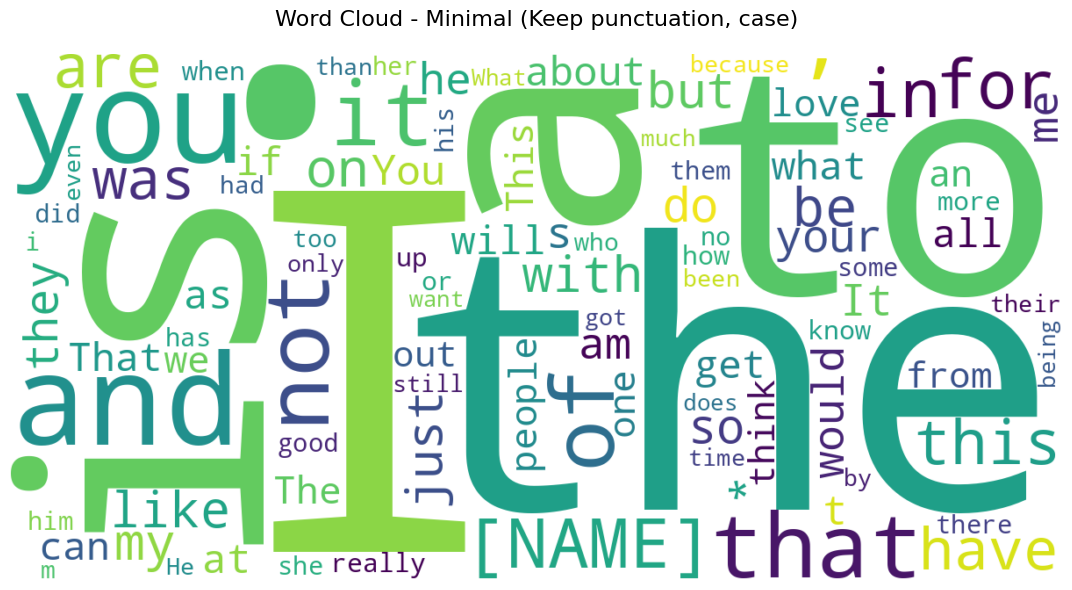

Word cloud saved to wordclouds/02_medium_preprocessing.png


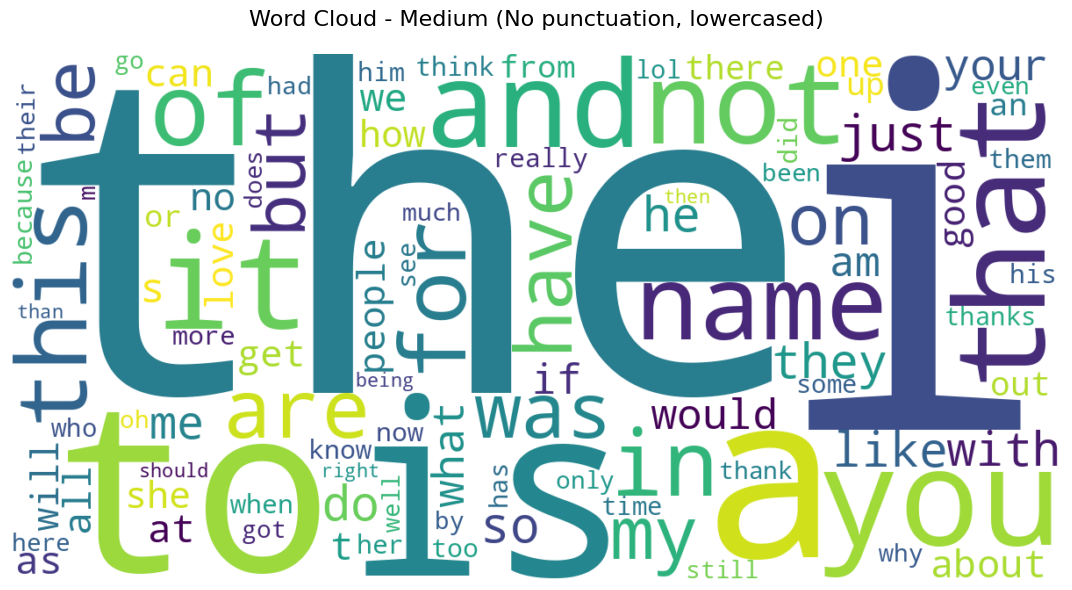

Word cloud saved to wordclouds/03_harsh_preprocessing.png


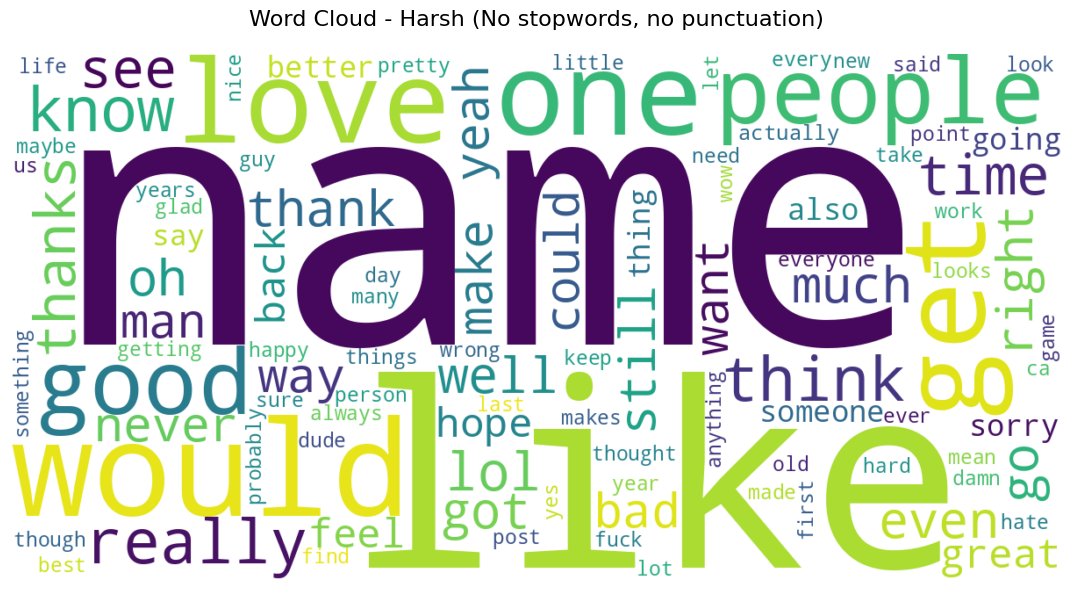

In [17]:
preprocessing_cols = {
    '01_minimal_preprocessing': 'Minimal (Keep punctuation, case)',
    '02_medium_preprocessing': 'Medium (No punctuation, lowercased)',
    '03_harsh_preprocessing': 'Harsh (No stopwords, no punctuation)'
}

for col, description in preprocessing_cols.items():
    wordcloud_from_text(
        dataset[col],
        title=f"Word Cloud - {description}",
        max_words=100,
        colormap='viridis',
        save_path=f'wordclouds/{col}.png'
    )

It is expected that the more preprocessing we do the worse the model will perform since this tasks constitutes in classifing the emotions of the text, which is normally deeply correlated to punctuation, stopwords, and repeated characters. 

### 2. Apply the Baseline Model.

We will use multiple models to evaluate the impact of different preprocessing techniques on the performance of emotion classification. The models we will use include:

In [18]:
MODELS = {
    'roberta_baseline': 'SamLowe/roberta-base-go_emotions',
    'bert_baseline': 'monologg/bert-base-cased-goemotions-original',
    'ekman_baseline': 'bhadresh-savani/bert-base-uncased-emotion'
}

In [19]:
experiments = [
    # (text_column, model_key, output_column_name)
    ('01_minimal_preprocessing', 'roberta_baseline', 'pred_roberta_minimal'),
    ('02_medium_preprocessing', 'roberta_baseline', 'pred_roberta_medium'),
    ('03_harsh_preprocessing', 'roberta_baseline', 'pred_roberta_harsh'), 
    ('01_minimal_preprocessing', 'bert_baseline', 'pred_bert_minimal'),
    ('02_medium_preprocessing', 'bert_baseline', 'pred_bert_medium'),
    ('03_harsh_preprocessing', 'bert_baseline', 'pred_bert_harsh'),
    ('01_minimal_preprocessing', 'ekman_baseline', 'pred_ekman_minimal'),
    ('02_medium_preprocessing', 'ekman_baseline', 'pred_ekman_medium'),
    ('03_harsh_preprocessing', 'ekman_baseline', 'pred_ekman_harsh')
]

In [20]:
emotion_cols = [
    col for col in dataset.columns
    if col not in ['text', '01_minimal_preprocessing', '02_medium_preprocessing', '03_harsh_preprocessing']
    and not col.startswith('pred_')
]

dataset['true_emotions_label'] = dataset[emotion_cols].apply(
    lambda row: [col for col, val in row.items() if val == 1],
    axis=1
)

print(dataset[['text', 'true_emotions_label']].head())

                                                text  \
0                   Wait until you try saying papi !   
1       I cackled at [NAME] face down in the corner.   
2  I saw this entire movie on YouTube and loved i...   
3  It's just a human problem. I lose track of how...   
4  Piss off a small percentage to gain an even la...   

                                 true_emotions_label  
0                        [desire, optimism, neutral]  
1                               [amusement, neutral]  
2          [approval, disappointment, love, sadness]  
3              [annoyance, disapproval, nervousness]  
4  [admiration, anger, annoyance, confusion, neut...  


In [21]:
test_data_fixed = dataset.head(5773).copy()
train_val_data = dataset.iloc[5773:10000].copy()

In [22]:
for text_col, model_key, output_col in experiments:
    # Print a header for clarity
    print(f"\n{'='*60}")
    print(f"Running: {model_key} on {text_col}")
    print(f"Output column: {output_col}")
    print('='*60)
    
    test_data_fixed = predict_with_model(
        df=test_data_fixed,
        text_column=text_col,
        model_name=MODELS[model_key],
        output_column=output_col,
        threshold=0.5
    )

print("\n" + "="*60)
print("ALL PREDICTION COLUMNS ADDED:")
print("="*60)
pred_cols = [col for col in test_data_fixed.columns if col.startswith('pred_')]
for col in pred_cols:
    print(f"- {col}")


Running: roberta_baseline on 01_minimal_preprocessing
Output column: pred_roberta_minimal
No token found
Loading model: SamLowe/roberta-base-go_emotions...


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

...

 Predictions saved to column: 'pred_ekman_medium'

Running: ekman_baseline on 03_harsh_preprocessing
Output column: pred_ekman_harsh
No token found
Loading model: bhadresh-savani/bert-base-uncased-emotion...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Generating predictions for 5773 rows...


Predicting with pred_ekman_harsh: 100%|██████████| 5773/5773 [01:04<00:00, 90.15it/s] 


 Predictions saved to column: 'pred_ekman_harsh'

ALL PREDICTION COLUMNS ADDED:
- pred_roberta_minimal
- pred_roberta_medium
- pred_roberta_harsh
- pred_bert_minimal
- pred_bert_medium
- pred_bert_harsh
- pred_ekman_minimal
- pred_ekman_medium
- pred_ekman_harsh


In [23]:
test_data_fixed[['pred_roberta_minimal', 'pred_roberta_medium', 'pred_roberta_harsh']].head()

,pred_roberta_minimal,pred_roberta_medium,pred_roberta_harsh
0,"{'neutral': 1, 'approval': 0, 'realization': 0...","{'neutral': 1, 'approval': 0, 'annoyance': 0, ...","{'neutral': 1, 'approval': 0, 'annoyance': 0, ..."
1,"{'joy': 1, 'amusement': 0, 'neutral': 0, 'exci...","{'amusement': 1, 'joy': 0, 'neutral': 0, 'exci...","{'amusement': 0, 'joy': 0, 'neutral': 0, 'exci..."
2,"{'love': 1, 'disappointment': 0, 'sadness': 0,...","{'love': 1, 'disappointment': 0, 'sadness': 0,...","{'love': 1, 'admiration': 0, 'neutral': 0, 'ap..."
3,"{'confusion': 0, 'neutral': 0, 'realization': ...","{'annoyance': 0, 'neutral': 0, 'realization': ...","{'disgust': 0, 'neutral': 0, 'embarrassment': ..."
4,"{'admiration': 1, 'annoyance': 0, 'anger': 0, ...","{'admiration': 0, 'annoyance': 0, 'anger': 0, ...","{'neutral': 0, 'surprise': 0, 'annoyance': 0, ..."


ERROR ANALYSIS

Now we will analyze the error of the prediction in 4 different ways

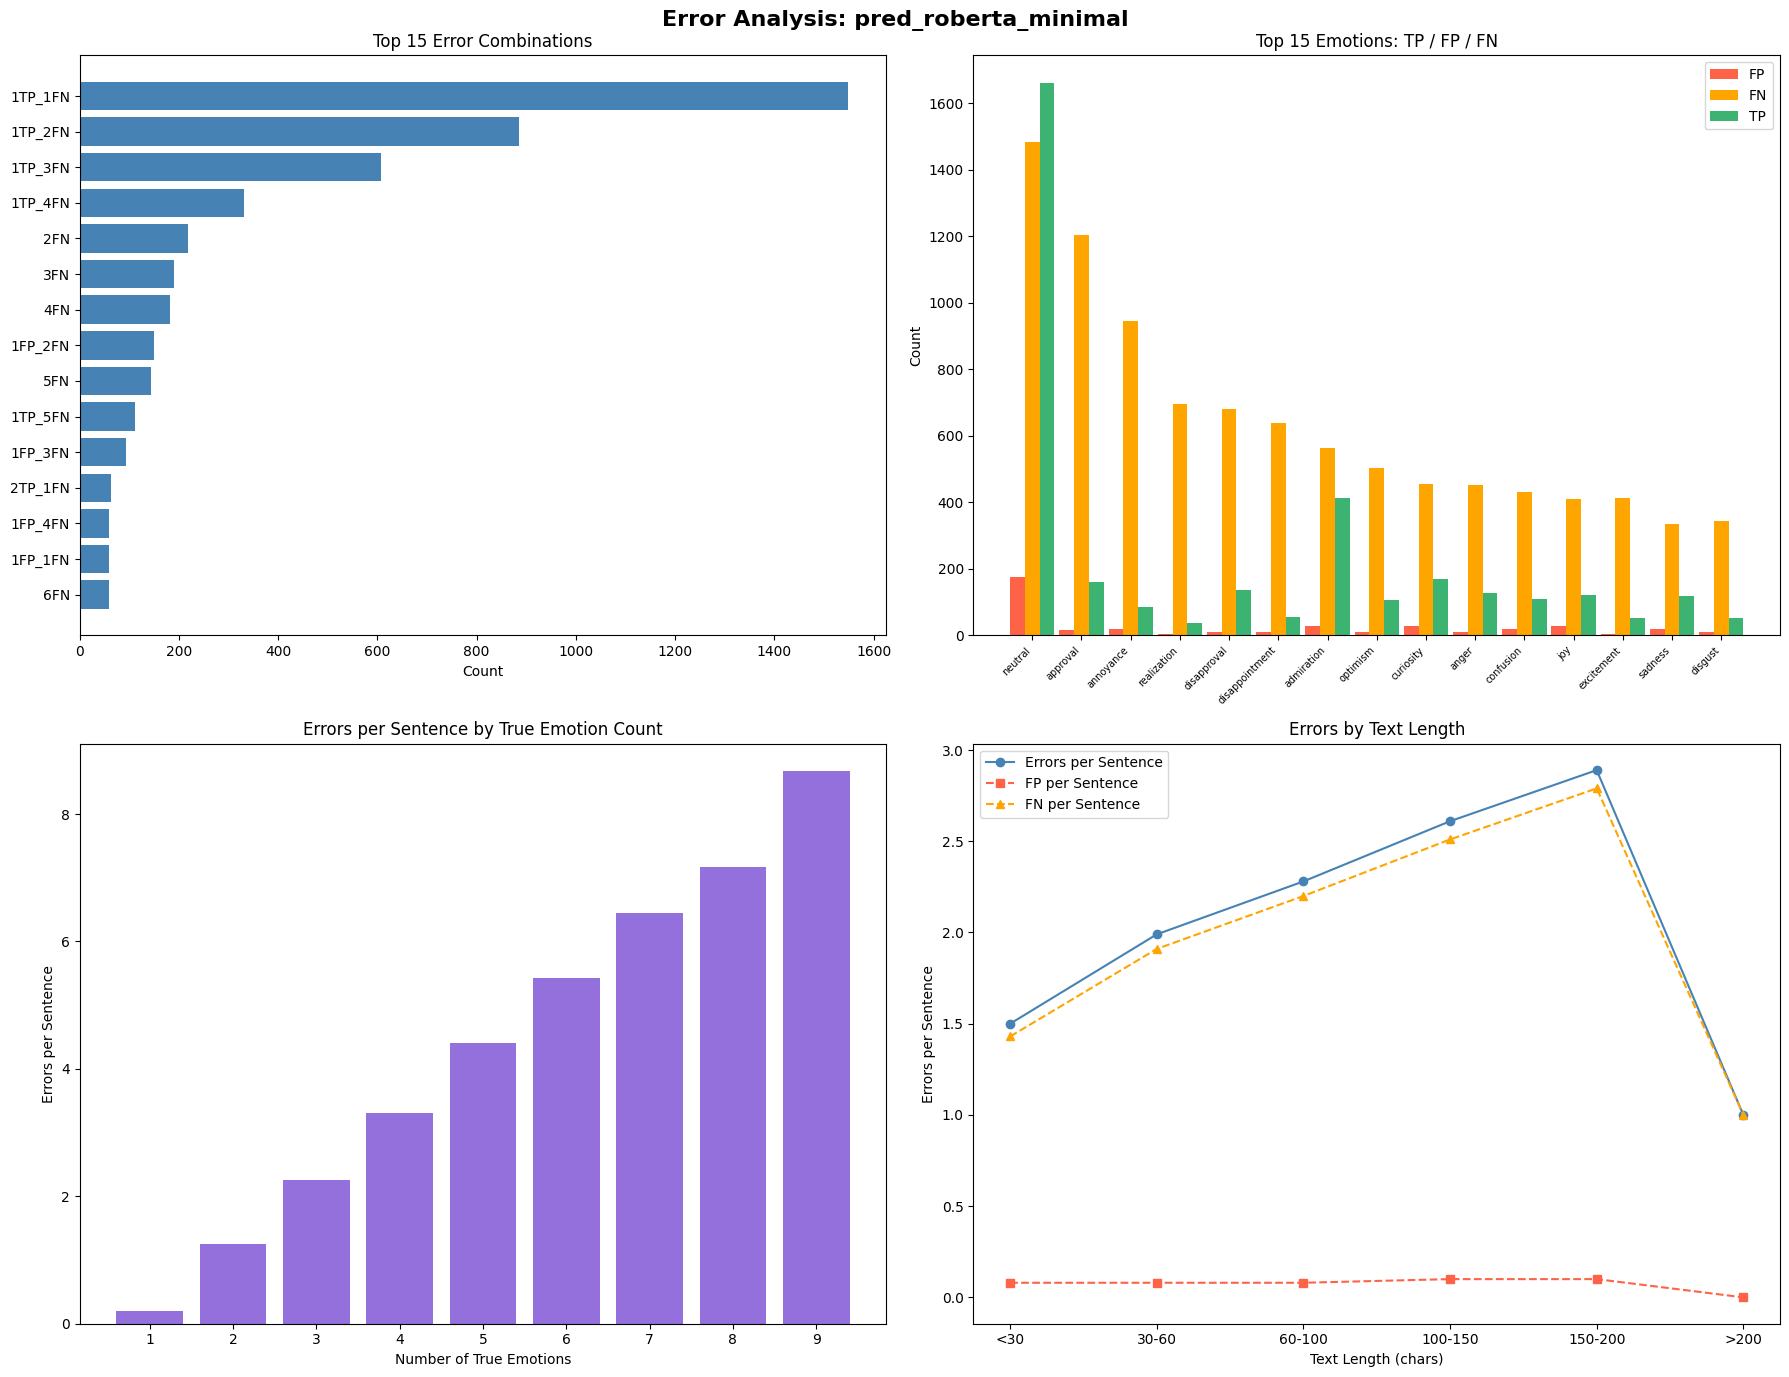

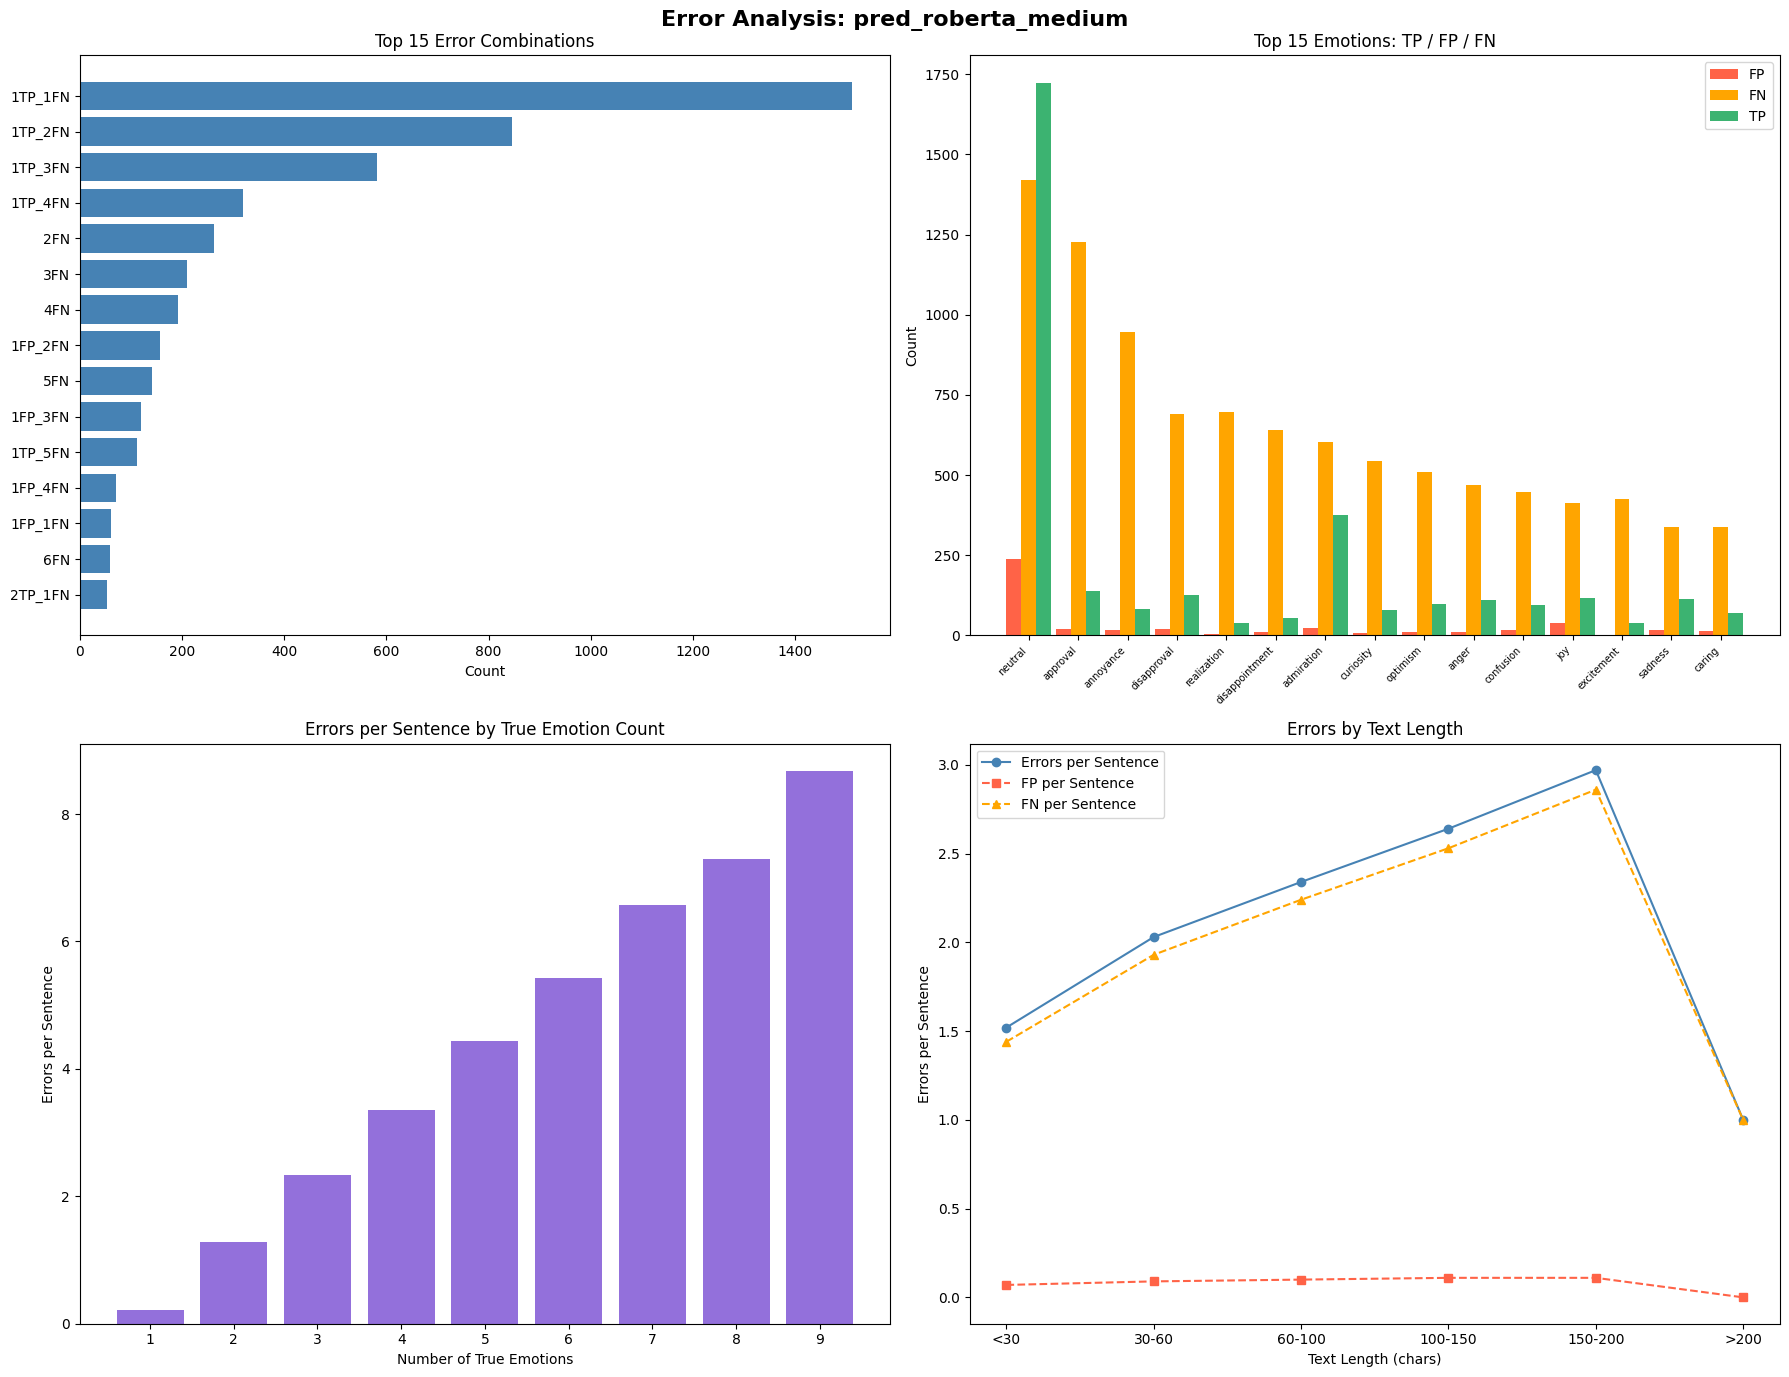

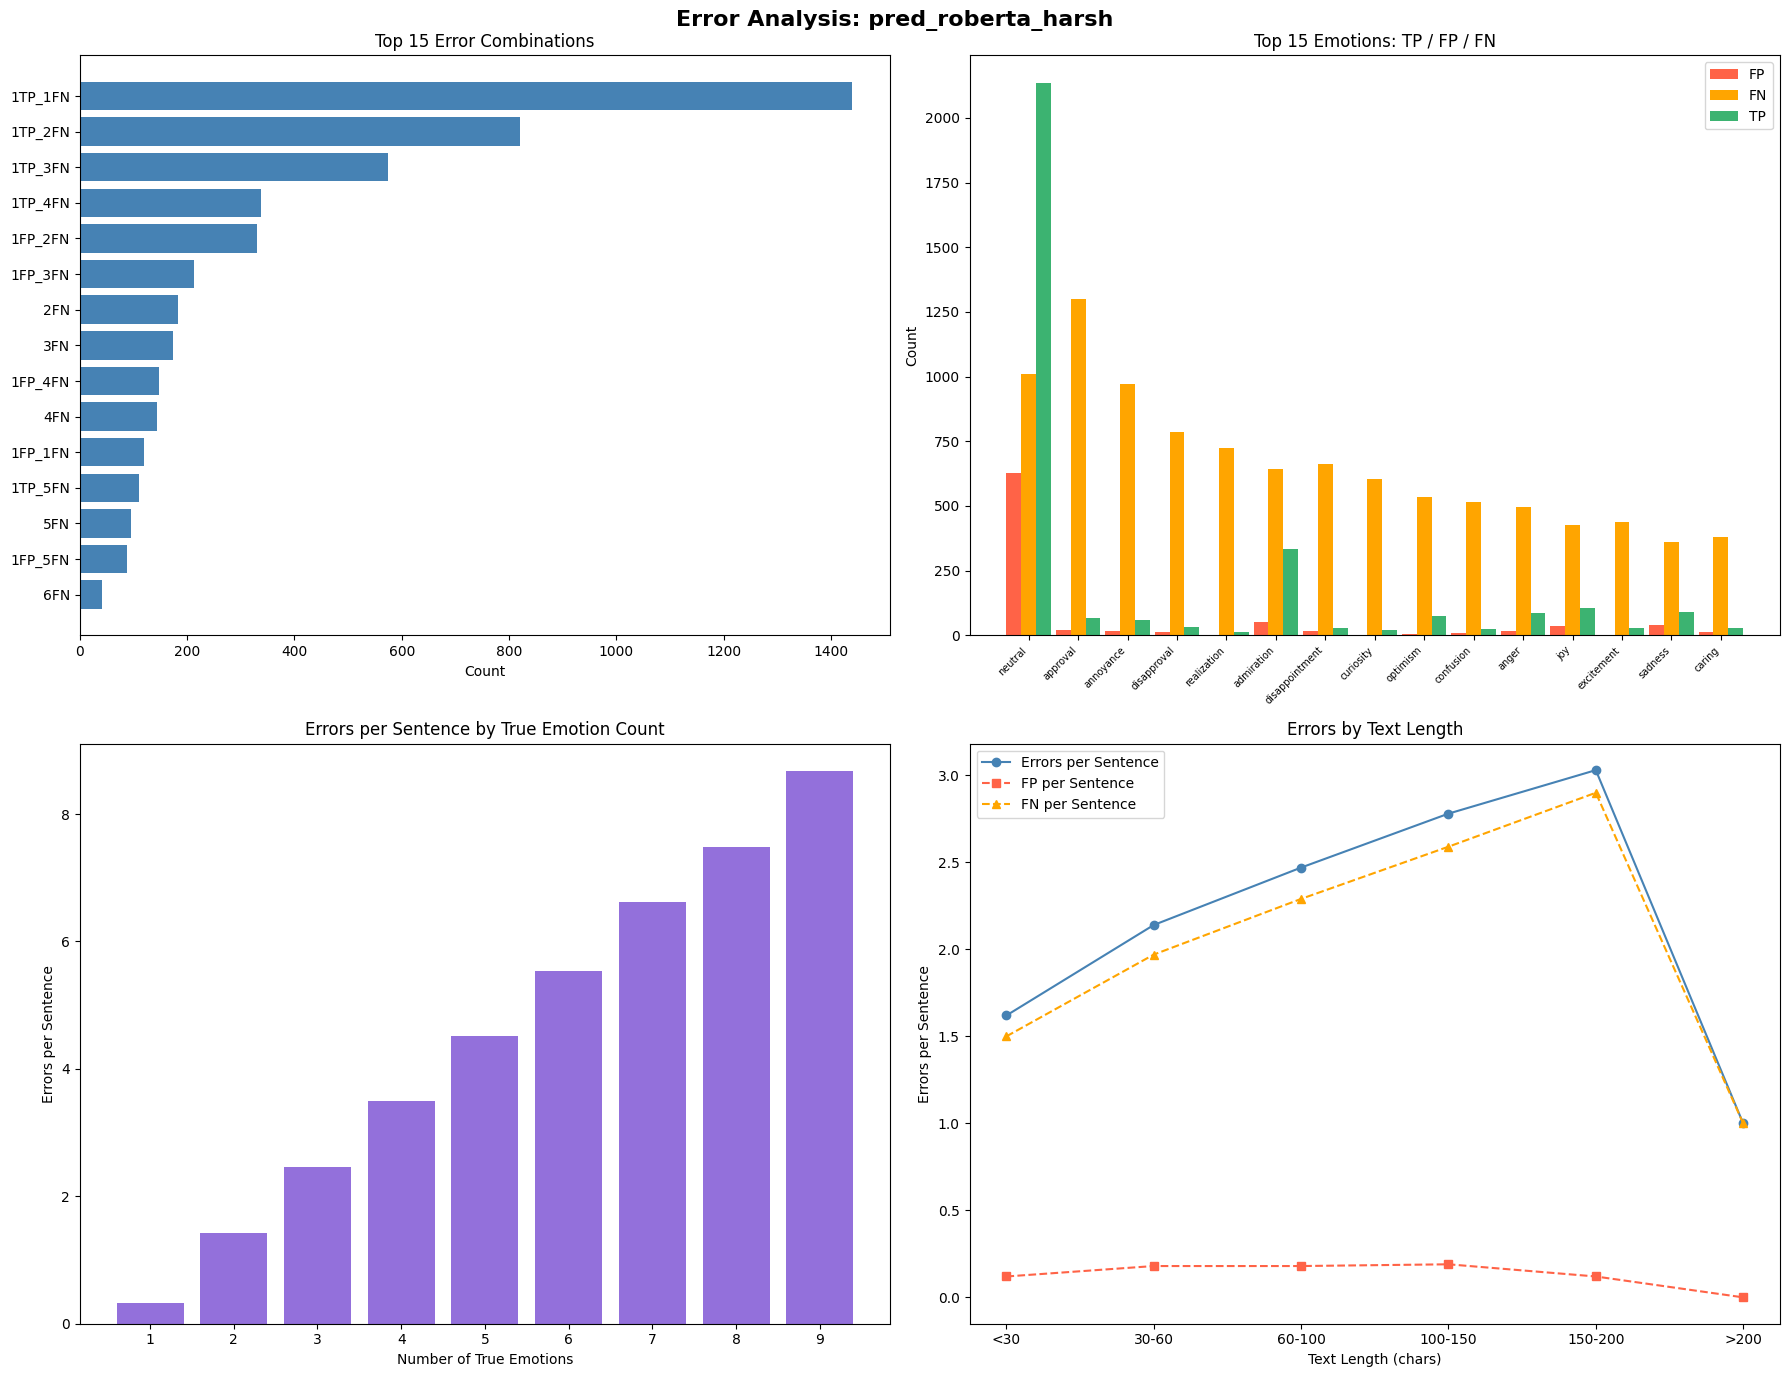

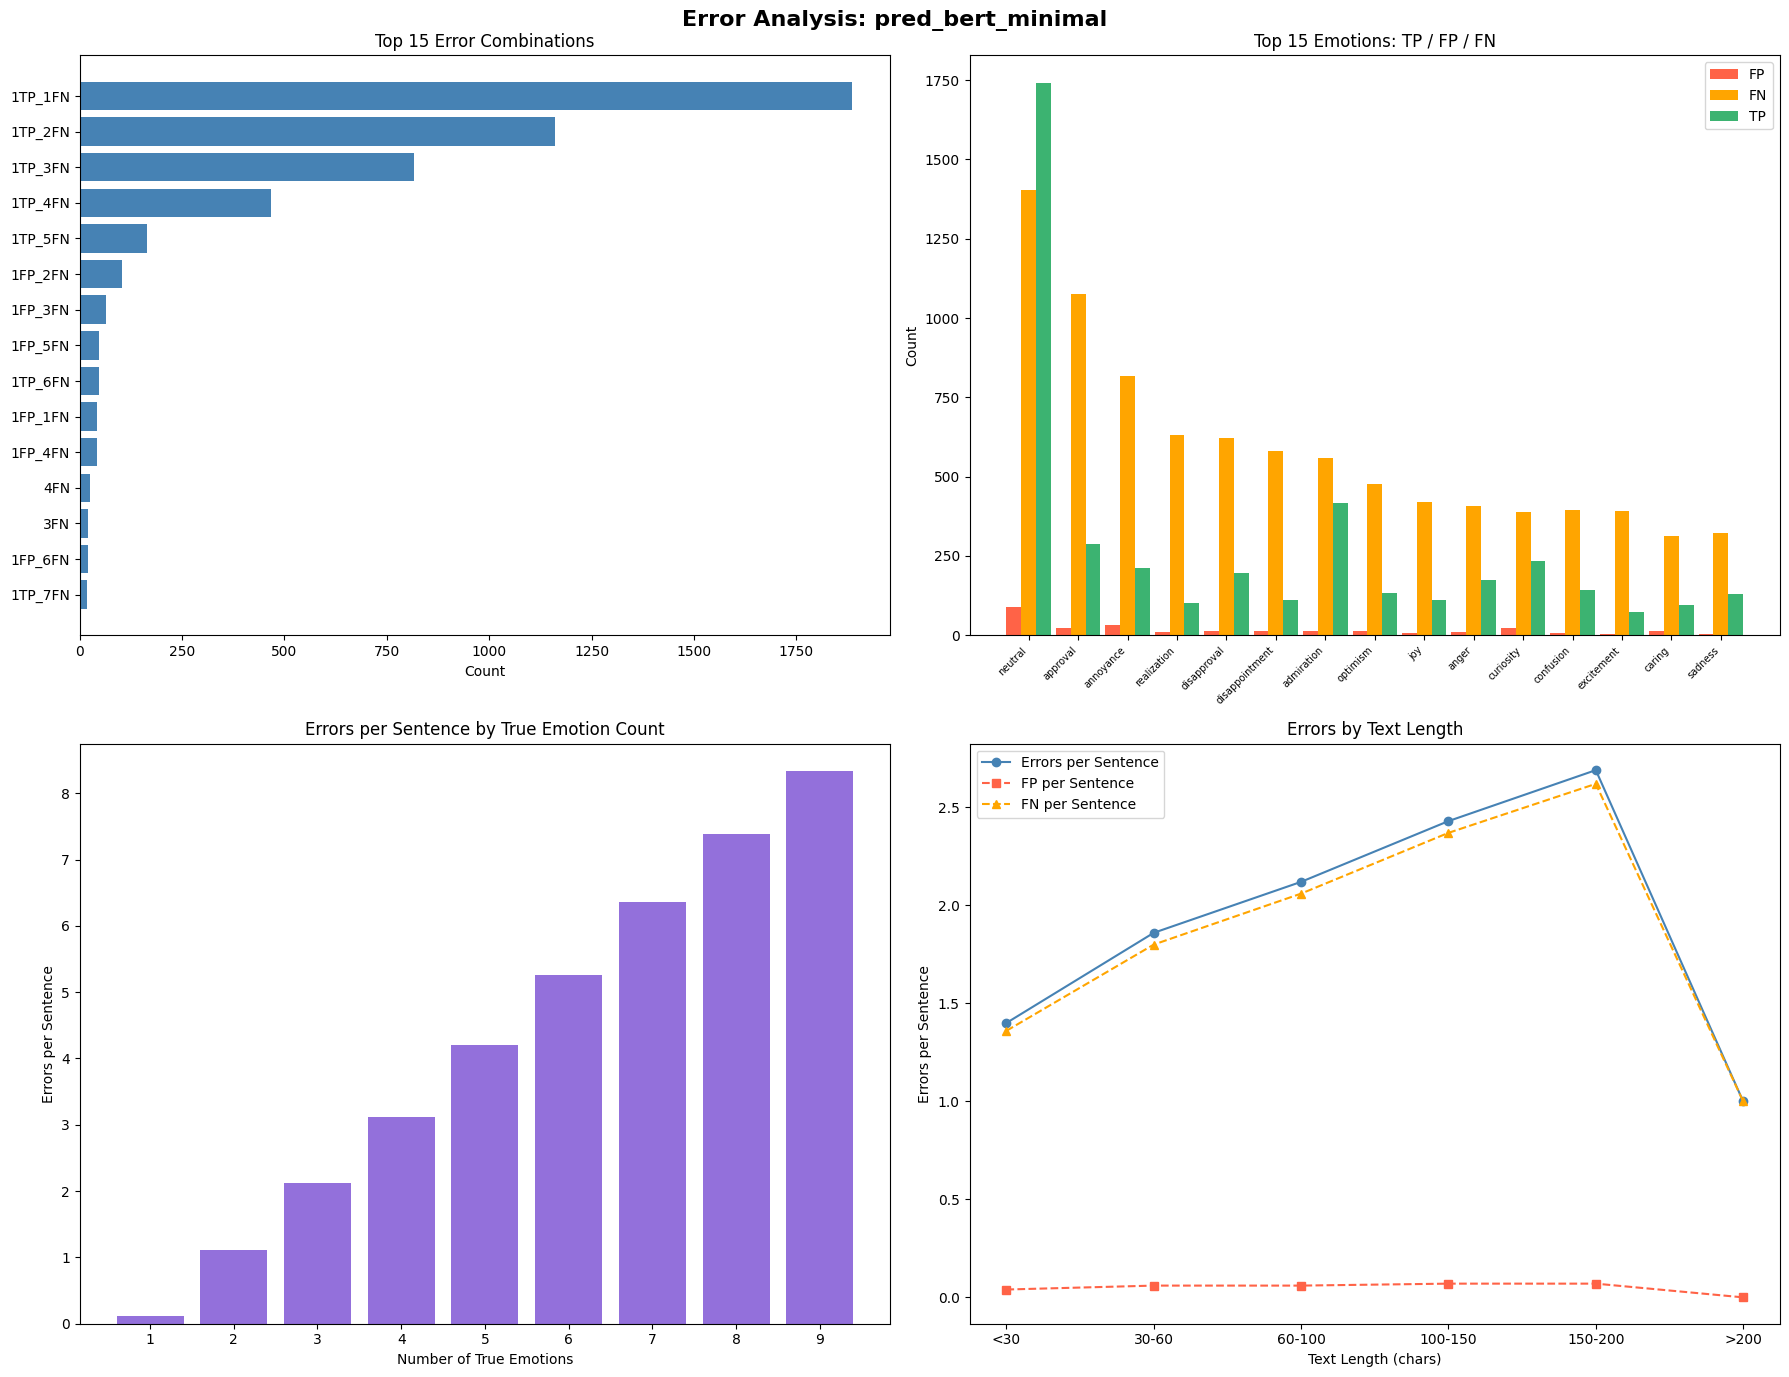

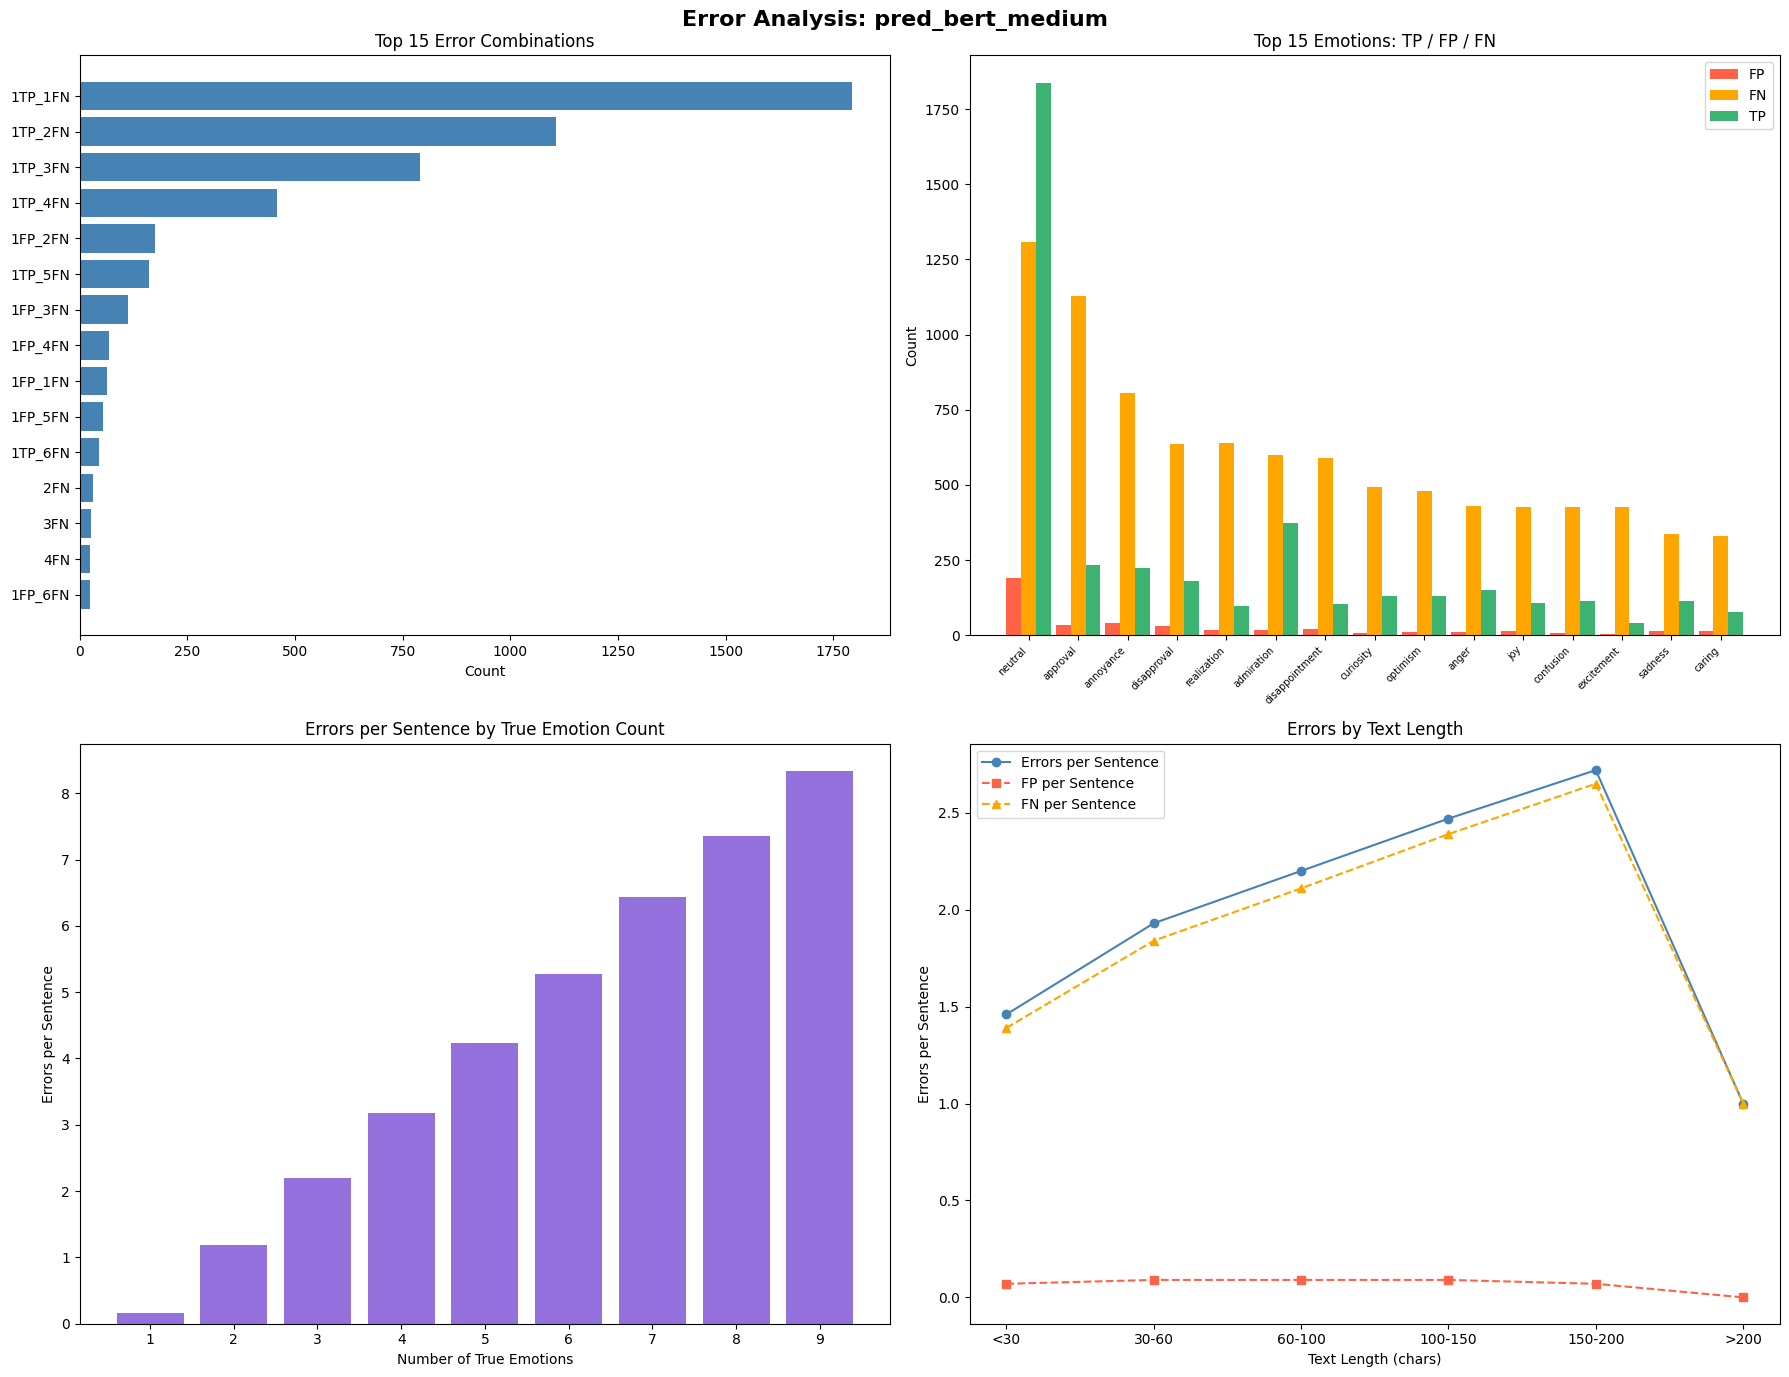

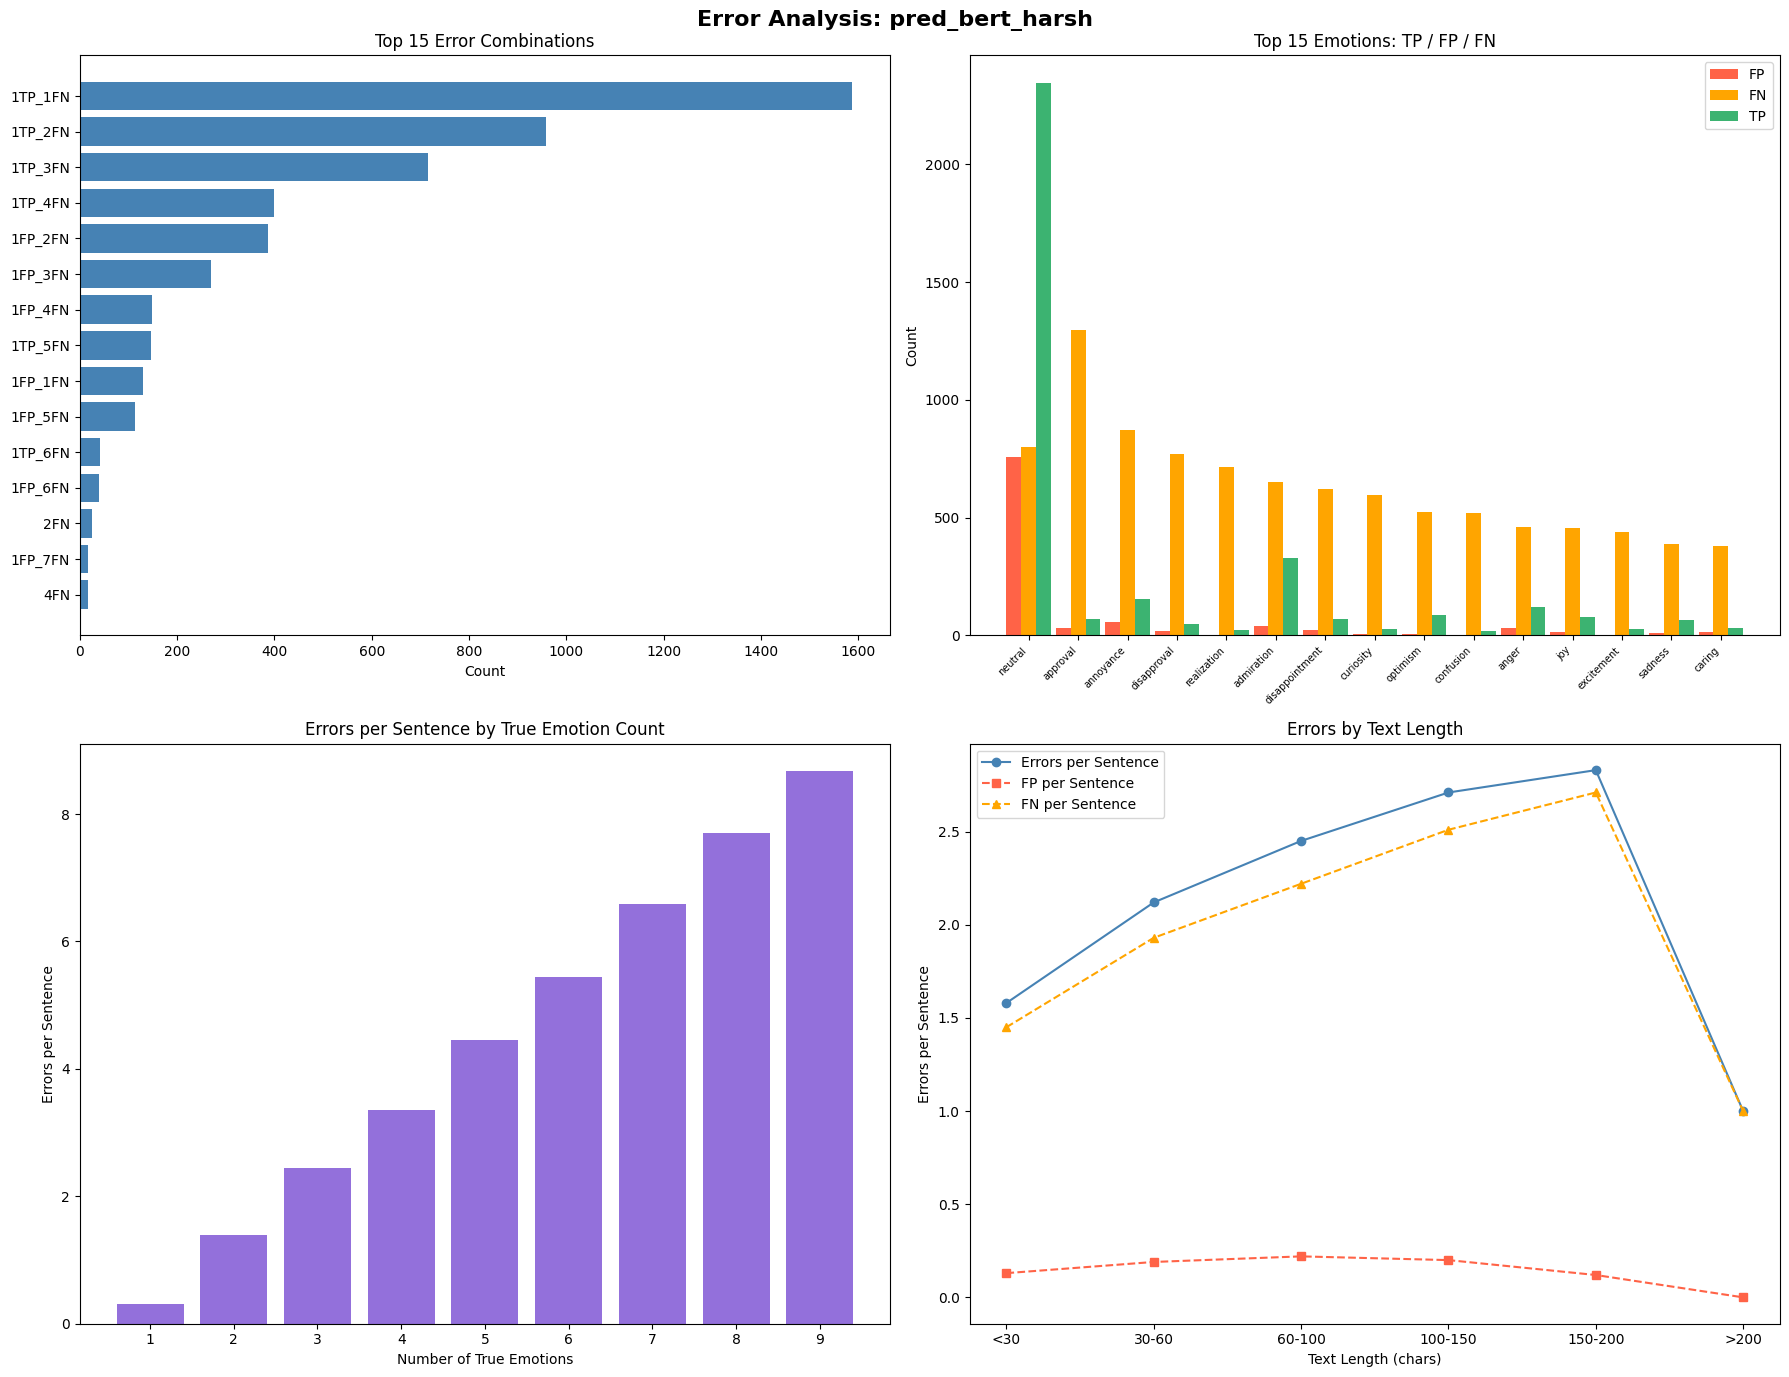

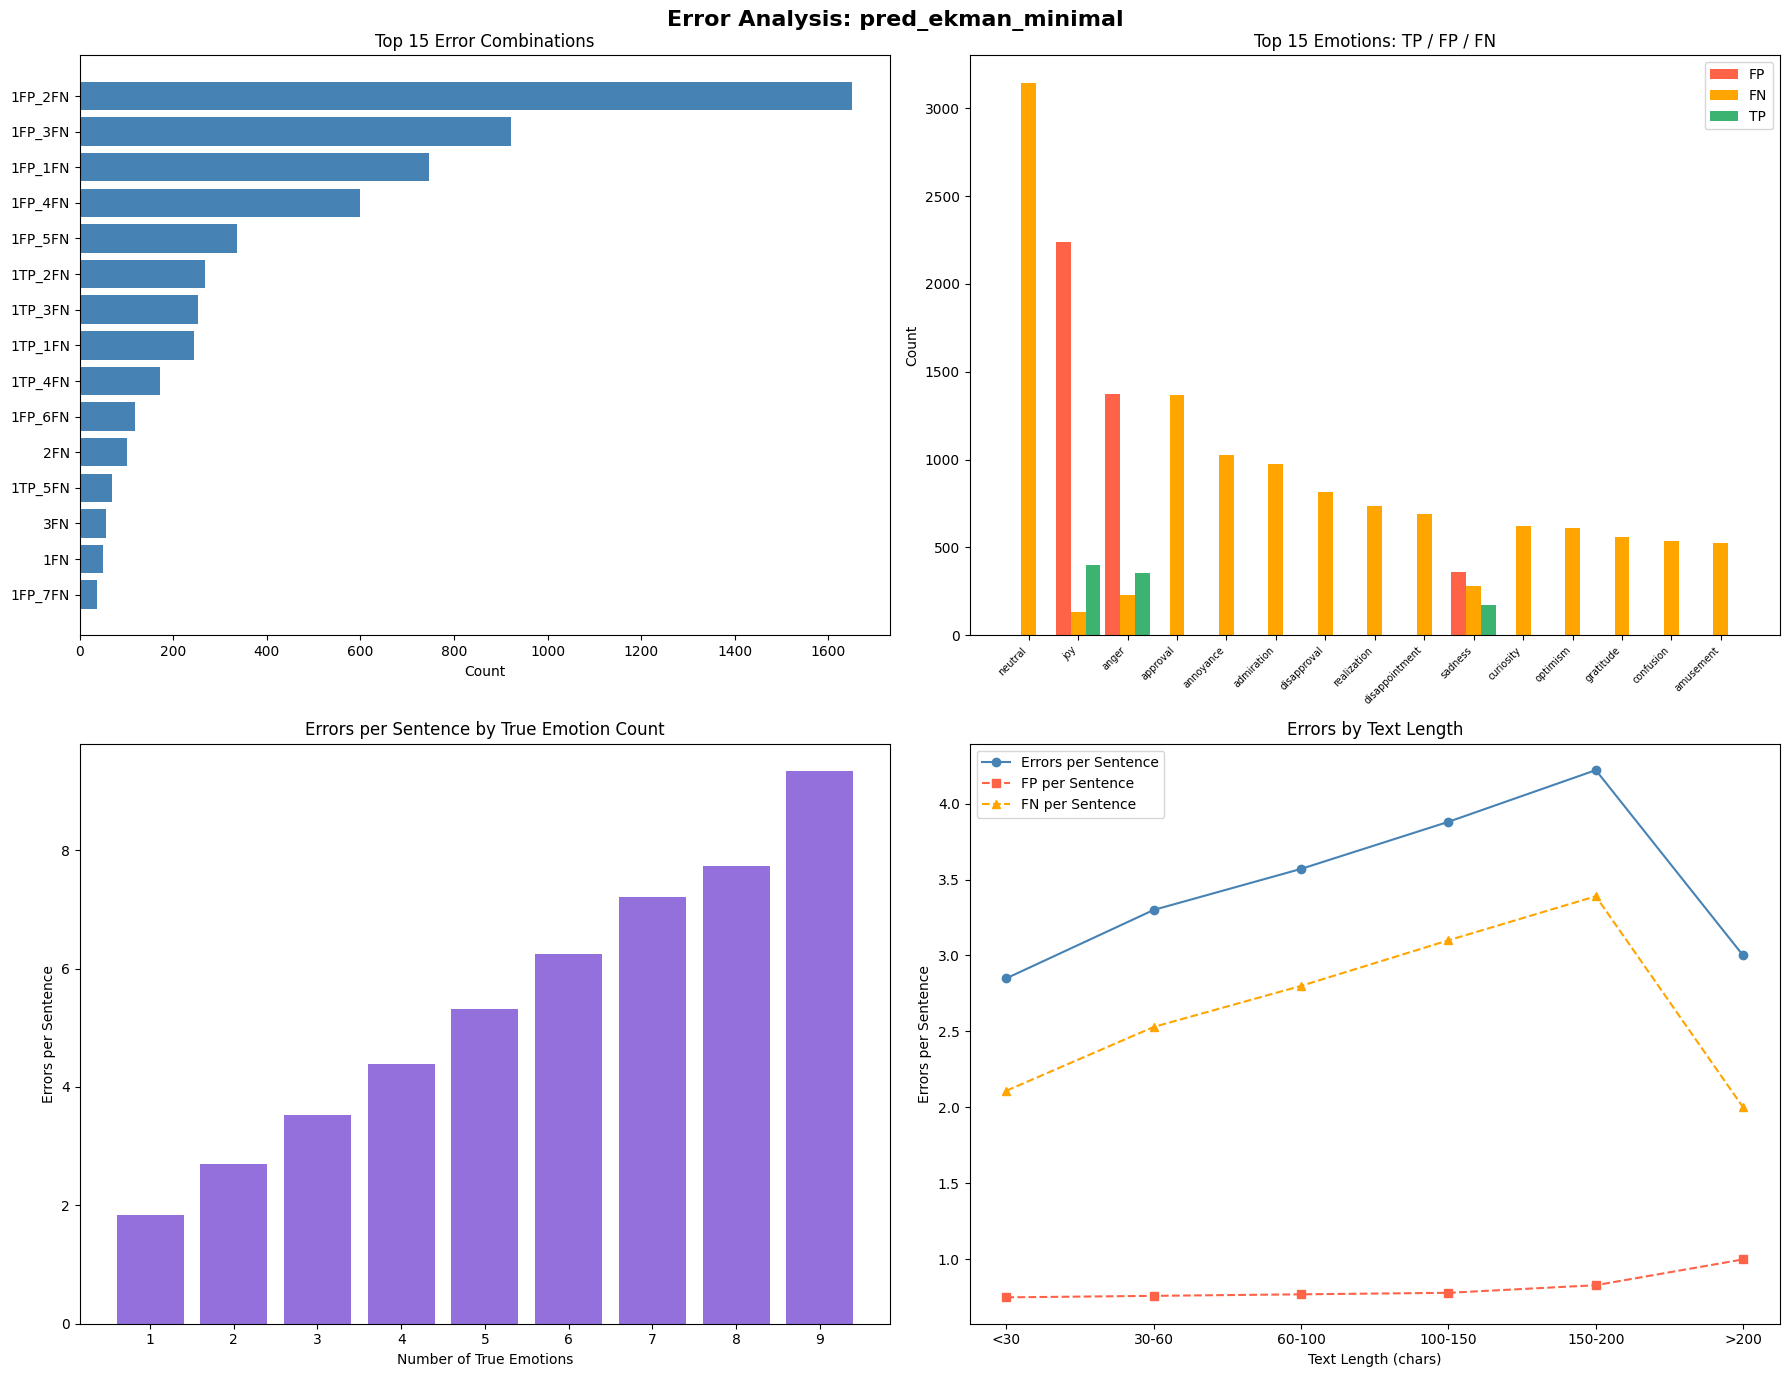

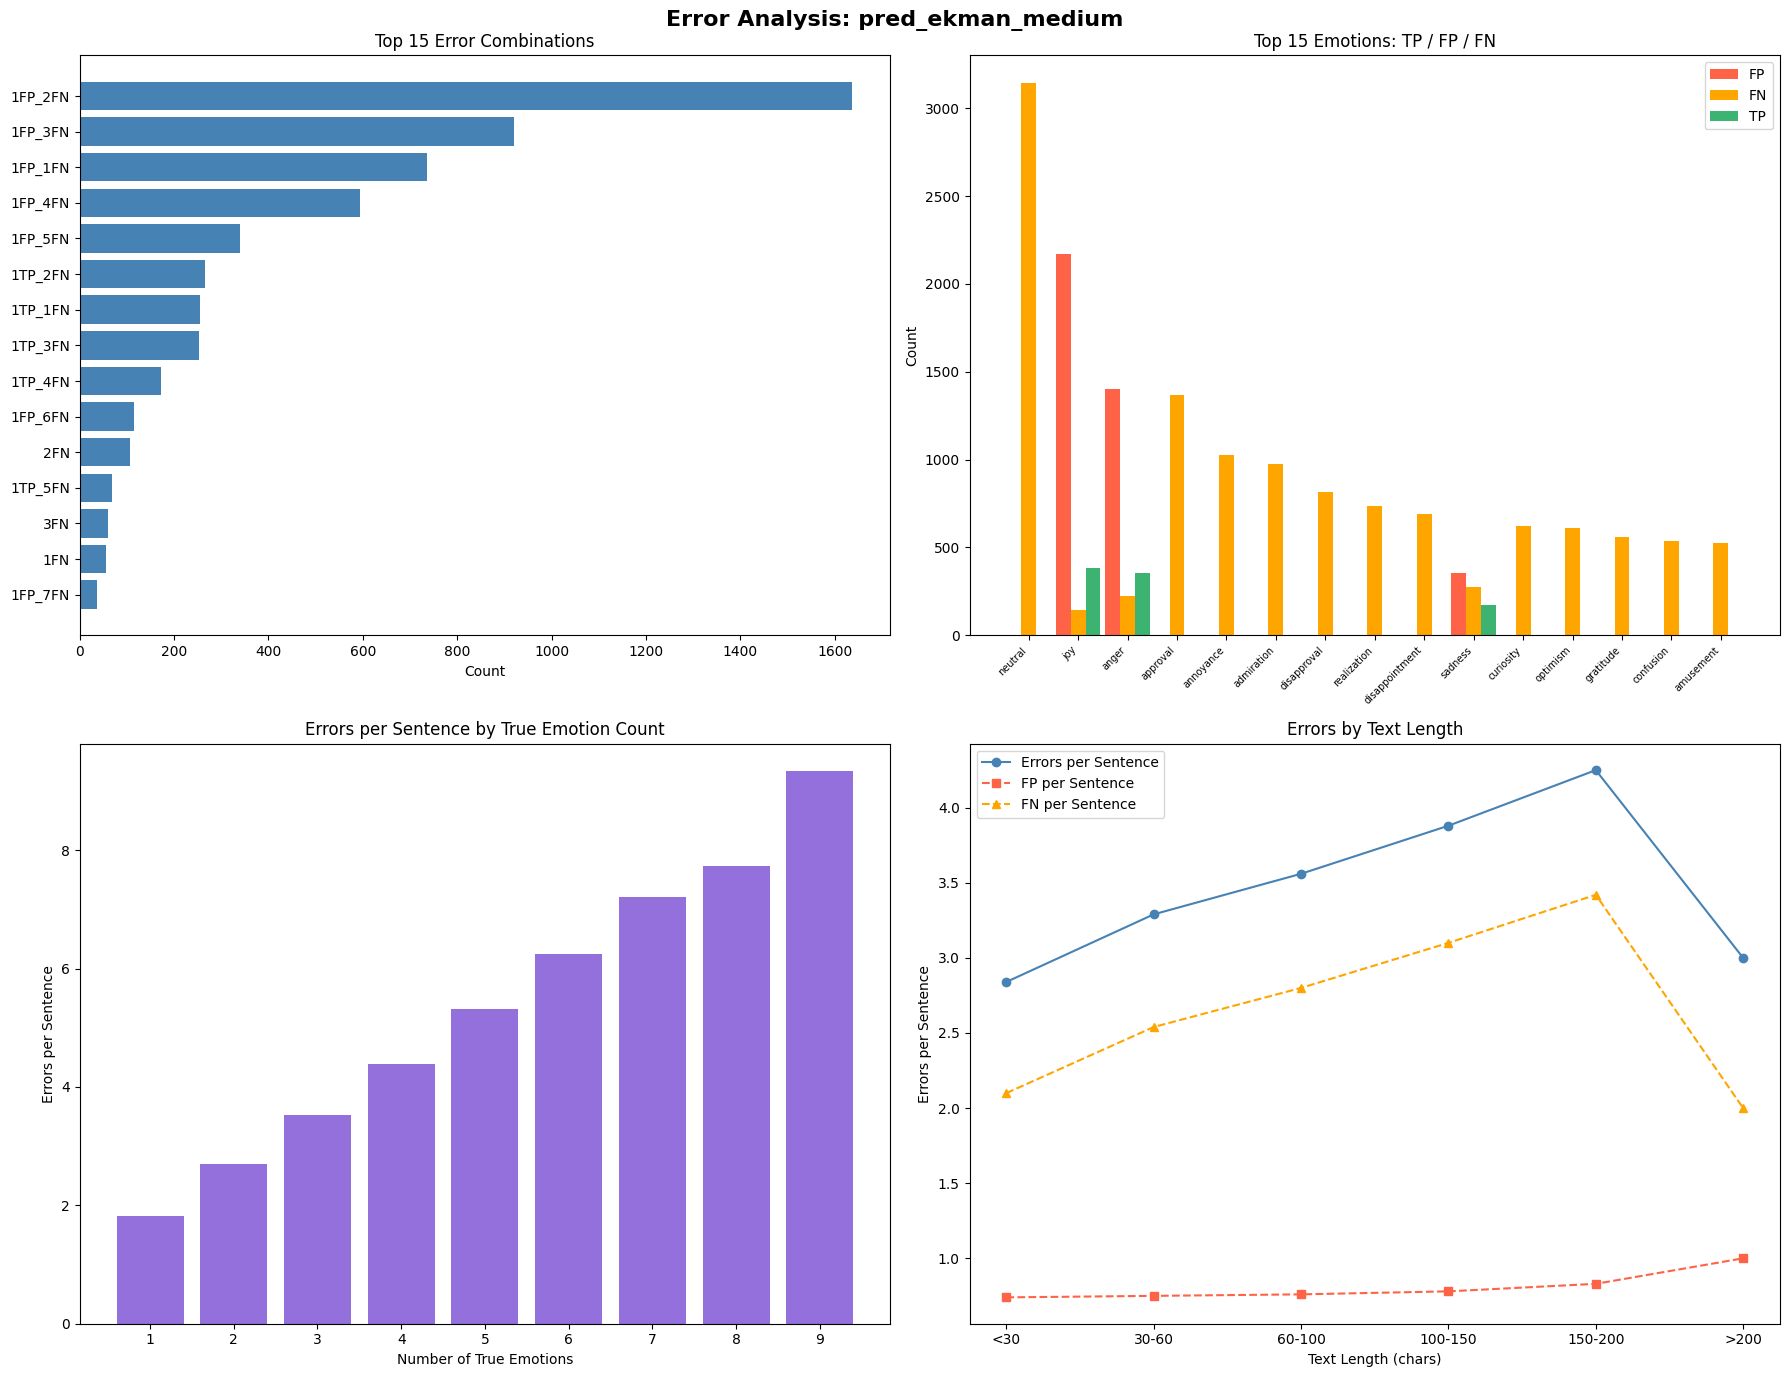

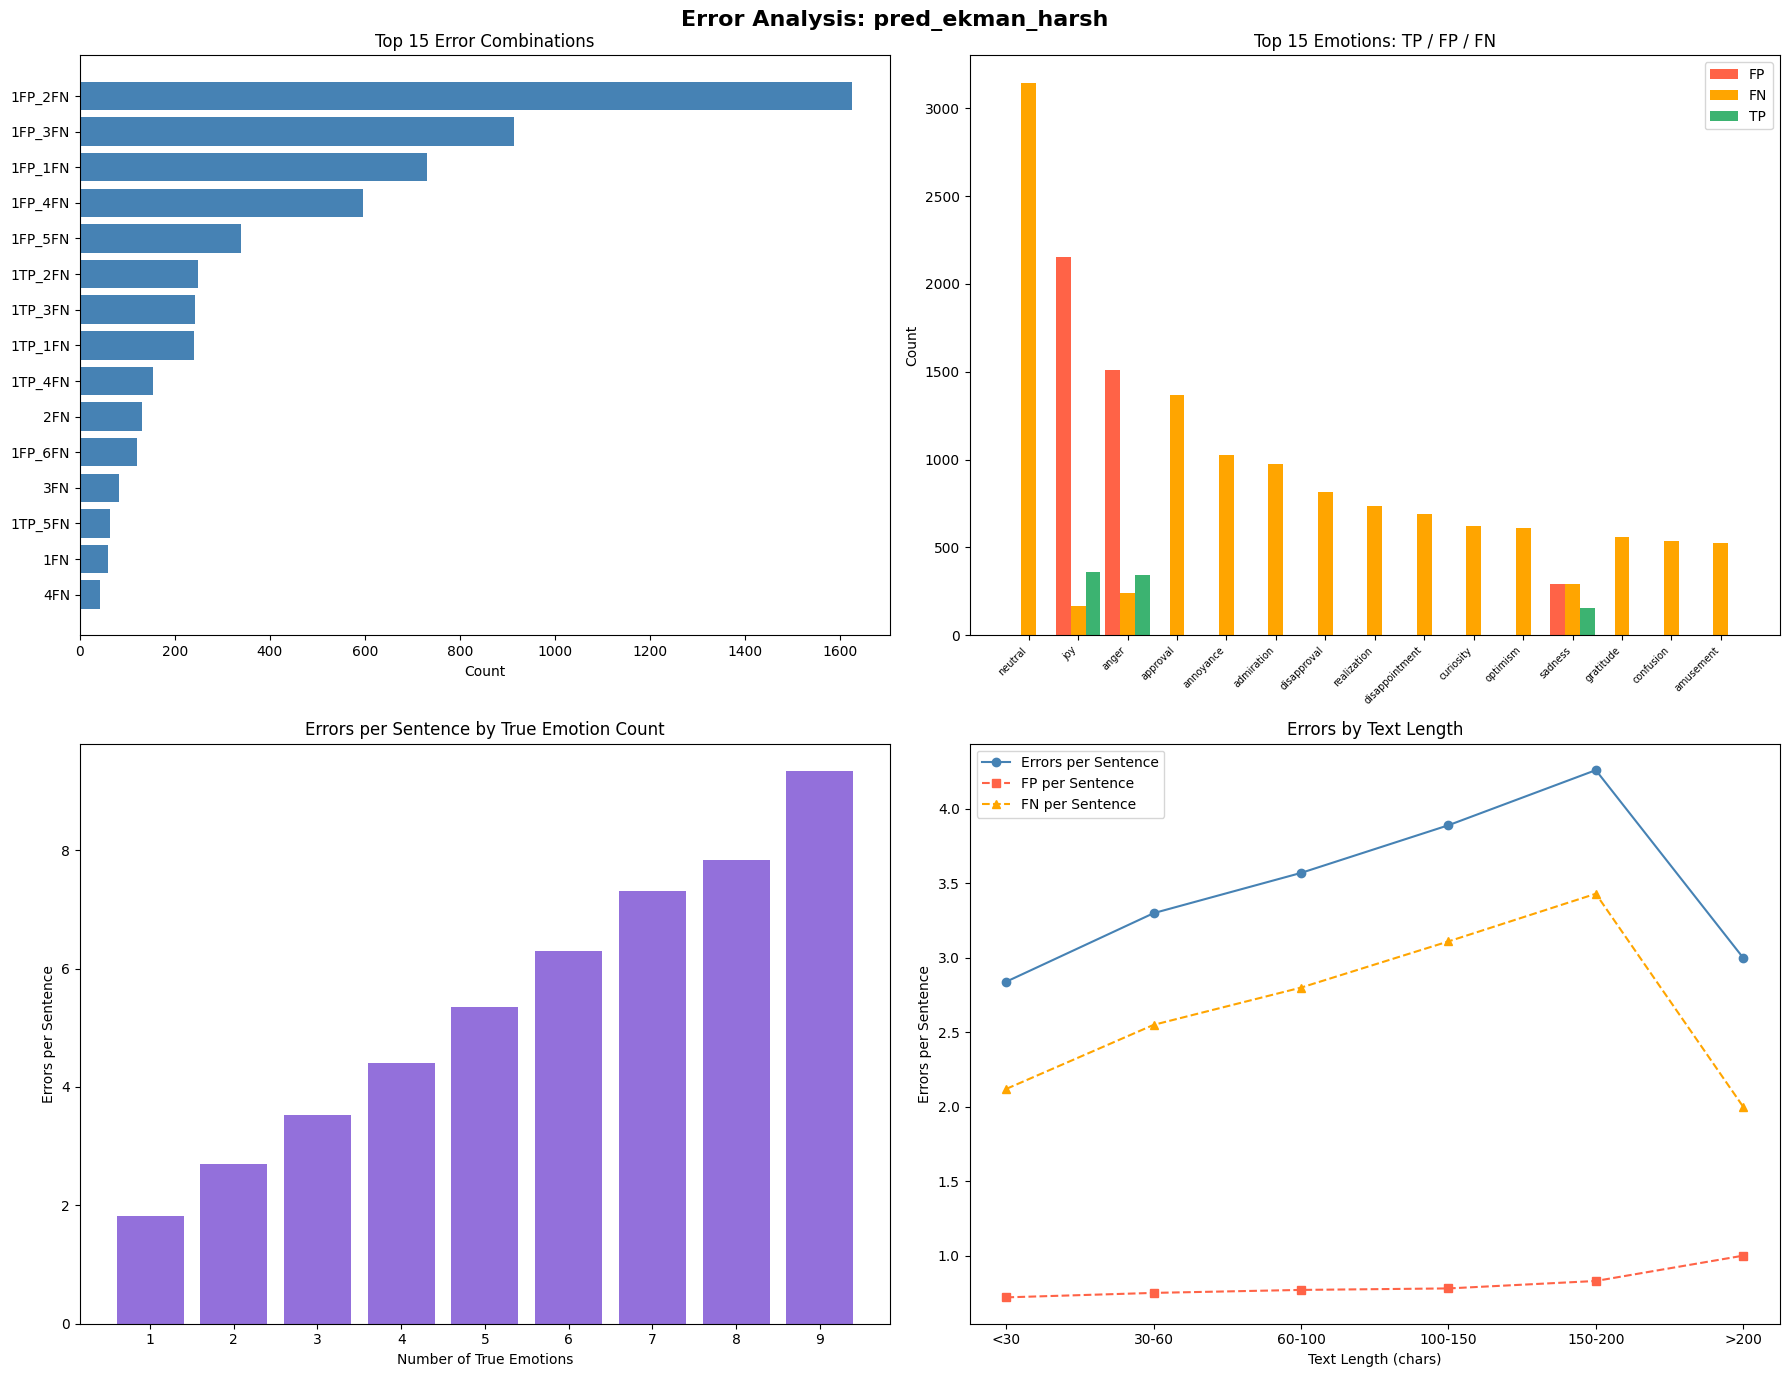

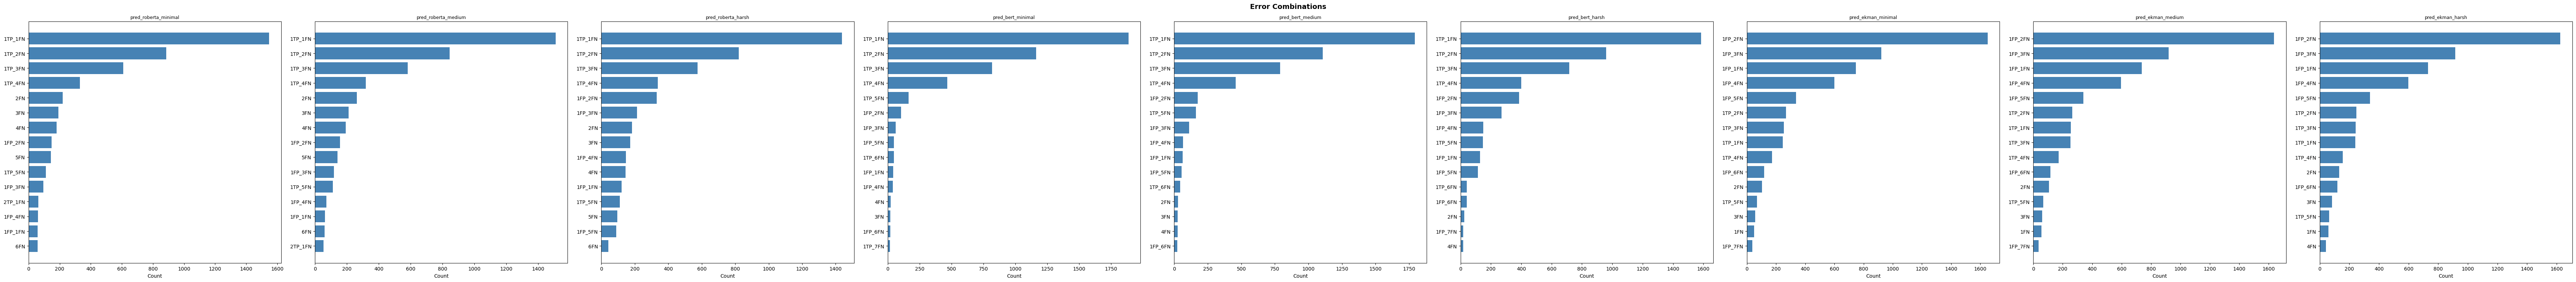

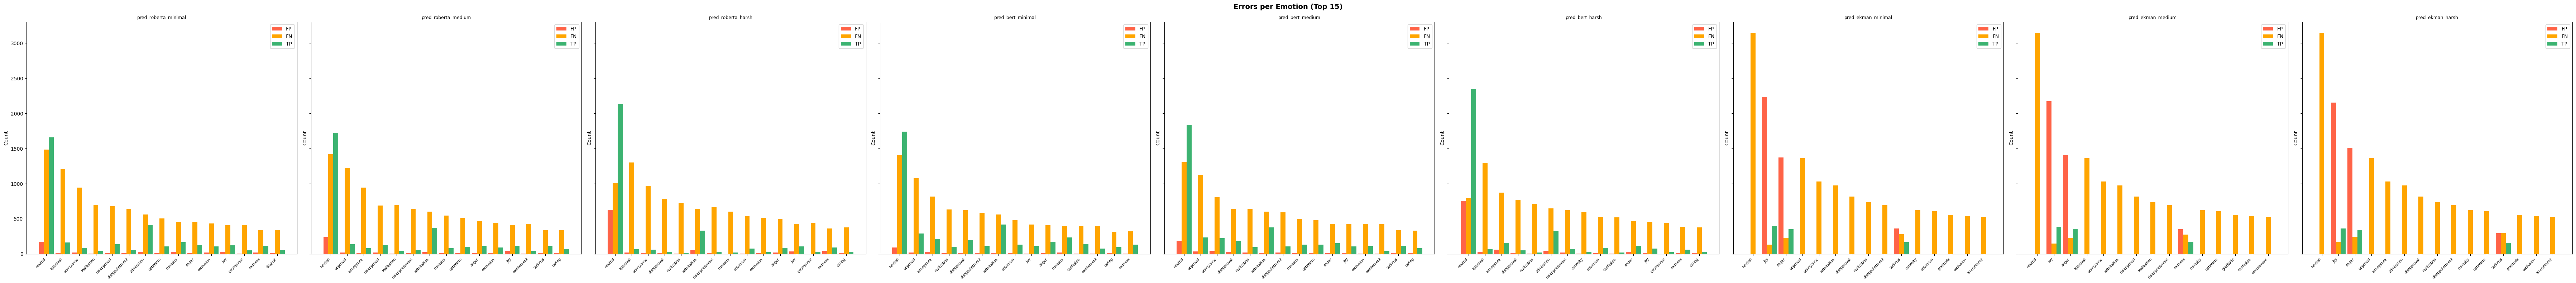

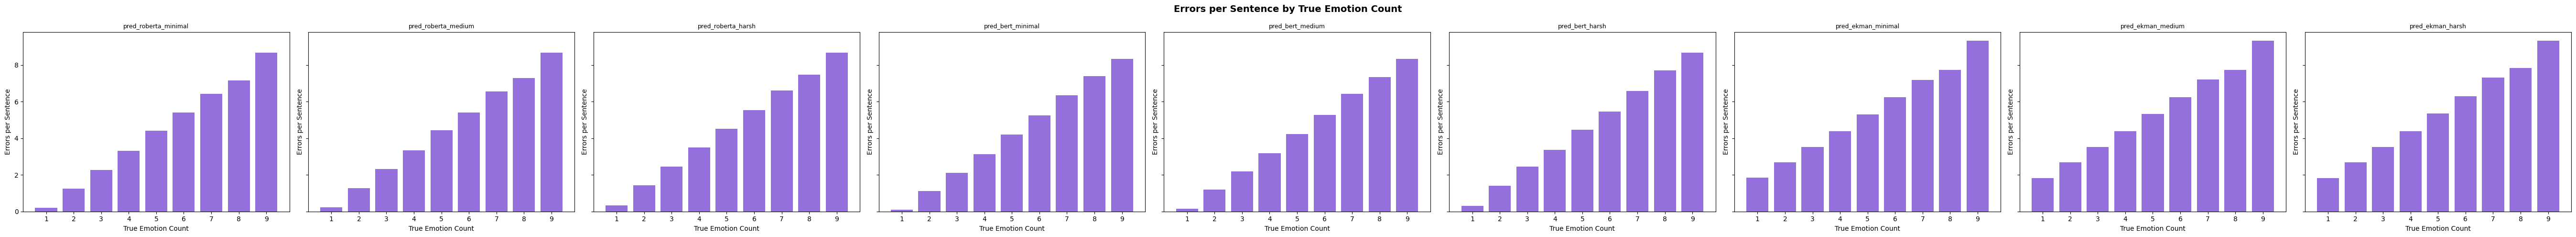

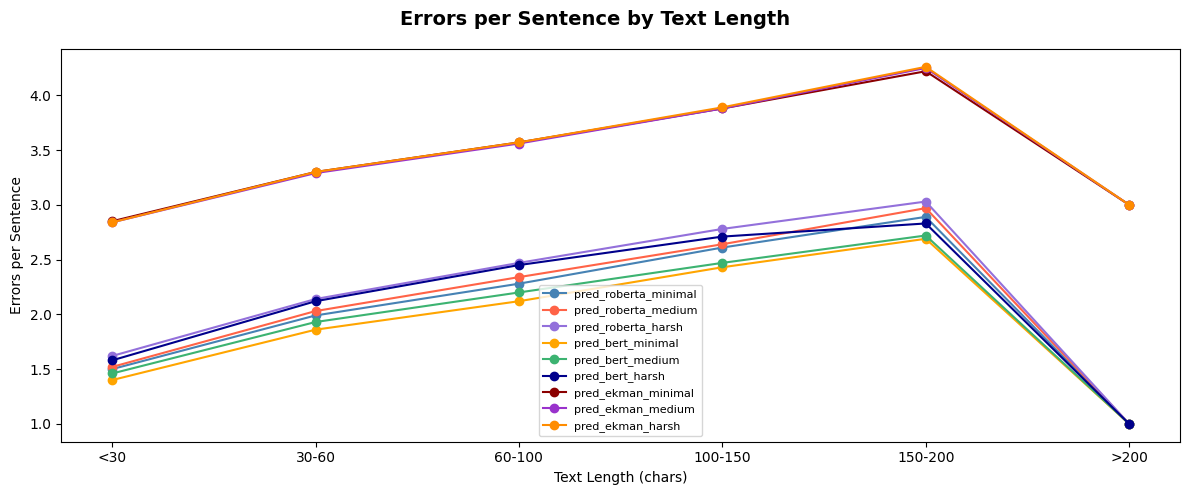

In [24]:
pred_cols = [col for col in test_data_fixed.columns if col.startswith("pred_") 
             and not col.endswith("_labels") and not col.endswith("_scores")]

run_error_analysis(test_data_fixed, pred_cols, emotion_cols)

# Side by side comparison for all models
compare_models_side_by_side(test_data_fixed, pred_cols, emotion_cols)

In [25]:
for col in pred_cols:
    label_col = f"{col}_labels"
    test_data_fixed[label_col] = test_data_fixed[col].apply(prediction_to_labels)

test_data_fixed[['true_emotions_label',
           'pred_roberta_minimal_labels',
           'pred_roberta_medium_labels',
           'pred_roberta_harsh_labels']].head()

,true_emotions_label,pred_roberta_minimal_labels,pred_roberta_medium_labels,pred_roberta_harsh_labels
0,"[desire, optimism, neutral]",[neutral],[neutral],[neutral]
1,"[amusement, neutral]",[joy],[amusement],[]
2,"[approval, disappointment, love, sadness]",[love],[love],[love]
3,"[annoyance, disapproval, nervousness]",[],[],[]
4,"[admiration, anger, annoyance, confusion, neut...",[admiration],[],[]


In [27]:
test_data_fixed

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,pred_ekman_harsh,pred_roberta_minimal_labels,pred_roberta_medium_labels,pred_roberta_harsh_labels,pred_bert_minimal_labels,pred_bert_medium_labels,pred_bert_harsh_labels,pred_ekman_minimal_labels,pred_ekman_medium_labels,pred_ekman_harsh_labels
0,Wait until you try saying papi !,0,0,0,0,0,0,0,0,1,...,"{'anger': 0, 'fear': 0, 'joy': 0, 'surprise': ...",[neutral],[neutral],[neutral],[neutral],[neutral],[neutral],[anger],[],[]
1,I cackled at [NAME] face down in the corner.,0,1,0,0,0,0,0,0,0,...,"{'anger': 1, 'fear': 0, 'love': 0, 'surprise':...",[joy],[amusement],[],[amusement],[amusement],[neutral],[anger],[anger],[anger]
2,I saw this entire movie on YouTube and loved i...,0,0,0,0,1,0,0,0,0,...,"{'love': 1, 'joy': 0, 'sadness': 0, 'anger': 0...",[love],[love],[love],[sadness],[love],[neutral],[joy],[love],[love]
3,It's just a human problem. I lose track of how...,0,0,0,1,0,0,0,0,0,...,"{'fear': 1, 'anger': 0, 'surprise': 0, 'sadnes...",[],[],[],[disappointment],[disappointment],[neutral],[fear],[fear],[fear]
4,Piss off a small percentage to gain an even la...,1,0,1,1,0,0,1,0,0,...,"{'joy': 1, 'surprise': 0, 'anger': 0, 'fear': ...",[admiration],[],[],[admiration],[annoyance],[disapproval],[joy],[joy],[joy]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5768,I thought we traded away our losers like [NAME...,0,0,0,1,0,0,0,0,0,...,"{'anger': 1, 'sadness': 0, 'joy': 0, 'fear': 0...",[neutral],[neutral],[neutral],[neutral],[neutral],[neutral],[anger],[anger],[anger]
5769,It was an edit friend - they are the same kid....,0,0,0,0,1,0,1,0,0,...,"{'sadness': 1, 'fear': 0, 'anger': 0, 'love': ...",[neutral],[neutral],[neutral],[neutral],[neutral],[neutral],[sadness],[sadness],[sadness]
5770,No one asked him,0,0,0,0,0,0,0,0,0,...,"{'anger': 1, 'fear': 0, 'joy': 0, 'surprise': ...",[neutral],[neutral],[neutral],[neutral],[neutral],[neutral],[anger],[anger],[anger]
5771,I'll try to stay patient.,0,0,0,1,0,0,0,0,0,...,"{'joy': 1, 'sadness': 0, 'fear': 0, 'anger': 0...",[optimism],[],[neutral],[optimism],[optimism],[neutral],[joy],[joy],[joy]


In [28]:
prediction_cols = {
    'Minimal Preprocessing Roberta': 'pred_roberta_minimal',
    'Medium Preprocessing Roberta': 'pred_roberta_medium',
    'Harsh Preprocessing Roberta': 'pred_roberta_harsh',
    'Minimal Preprocessing BERT': 'pred_bert_minimal',
    'Medium Preprocessing BERT': 'pred_bert_medium',
    'Harsh Preprocessing BERT': 'pred_bert_harsh',
    'Minimal Preprocessing Ekman': 'pred_ekman_minimal',
    'Medium Preprocessing Ekman': 'pred_ekman_medium',
    'Harsh Preprocessing Ekman': 'pred_ekman_harsh'
}

print("Prediction columns in the dataset:")
for col in prediction_cols.values():
    print(f"  - {col}")

Prediction columns in the dataset:
  - pred_roberta_minimal
  - pred_roberta_medium
  - pred_roberta_harsh
  - pred_bert_minimal
  - pred_bert_medium
  - pred_bert_harsh
  - pred_ekman_minimal
  - pred_ekman_medium
  - pred_ekman_harsh


In [29]:
comparison_df = create_model_comparison_df(
    df=test_data_fixed,  # or dataset_with_predictions
    emotion_cols=emotion_cols,
    prediction_cols=prediction_cols
)

In [30]:
comparison_df.head(9)

,model,micro_f1,macro_f1,samples_f1,weighted_f1,exact_match_ratio,hamming_loss,micro_precision,micro_recall,macro_precision,macro_recall,total_samples,error_count
0,Minimal Preprocessing Roberta,0.430106,0.325020,0.479596,0.396434,0.135805,0.076495,0.905316,0.282053,0.801233,0.224392,5773,0
1,Medium Preprocessing Roberta,0.416624,0.308876,0.463694,0.379229,0.132340,0.077893,0.892063,0.271777,0.791517,0.212881,5773,0
2,Harsh Preprocessing Roberta,0.388304,0.246649,0.437383,0.324832,0.123333,0.082311,0.810868,0.255274,0.742300,0.174578,5773,0
3,Minimal Preprocessing BERT,0.481666,0.385466,0.549782,0.462367,0.137017,0.071274,0.941766,0.323581,0.897093,0.257681,5773,0
4,Medium Preprocessing BERT,0.463417,0.360929,0.528022,0.438331,0.133380,0.073680,0.909782,0.310887,0.869780,0.241993,5773,0
5,Harsh Preprocessing BERT,0.411230,0.263749,0.470566,0.347466,0.121947,0.080956,0.804153,0.276250,0.792678,0.183213,5773,0
6,Minimal Preprocessing Ekman,0.098689,0.053839,0.091459,0.040489,0.007622,0.122943,0.197603,0.065768,0.057496,0.081434,5773,0
7,Medium Preprocessing Ekman,0.099601,0.055655,0.092783,0.041759,0.007968,0.122702,0.200000,0.066312,0.058033,0.082310,5773,0
8,Harsh Preprocessing Ekman,0.093945,0.053147,0.087893,0.039740,0.008315,0.123030,0.190714,0.062322,0.058497,0.077258,5773,0


In [31]:
best_model = comparison_df.loc[comparison_df['weighted_f1'].idxmax(), 'model']
best_f1 = comparison_df.loc[comparison_df['weighted_f1'].idxmax(), 'weighted_f1']
print(f"\n Best model based on weighted F1: {best_model} ({best_f1:.4f})")


 Best model based on weighted F1: Minimal Preprocessing BERT (0.4624)


In [32]:
cooc, pred_binary = build_cooccurrence_table(
    true_df=test_data_fixed,
    pred_series=test_data_fixed["pred_roberta_minimal"],
    emotion_cols=emotion_cols
)
print(cooc)

/content/ailab/source/error_analysis.py:294: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pred_binary.iloc[idx][emotion] = 1


               admiration_TP  admiration_FP  admiration_FN  amusement_TP  \
admiration_TP              0              0              0             8   
admiration_FP              0              0              0             0   
admiration_FN              0              0              0            30   
amusement_TP               8              0             30             0   
amusement_FP               4              0              0             0   
...                      ...            ...            ...           ...   
surprise_FP                0              0              3             0   
surprise_FN               24              2             36             8   
neutral_TP                 0              0             86             1   
neutral_FP                 0              0             14             0   
neutral_FN                92             16            124            93   

               amusement_FP  amusement_FN  anger_TP  anger_FP  anger_FN  \
admiration_T

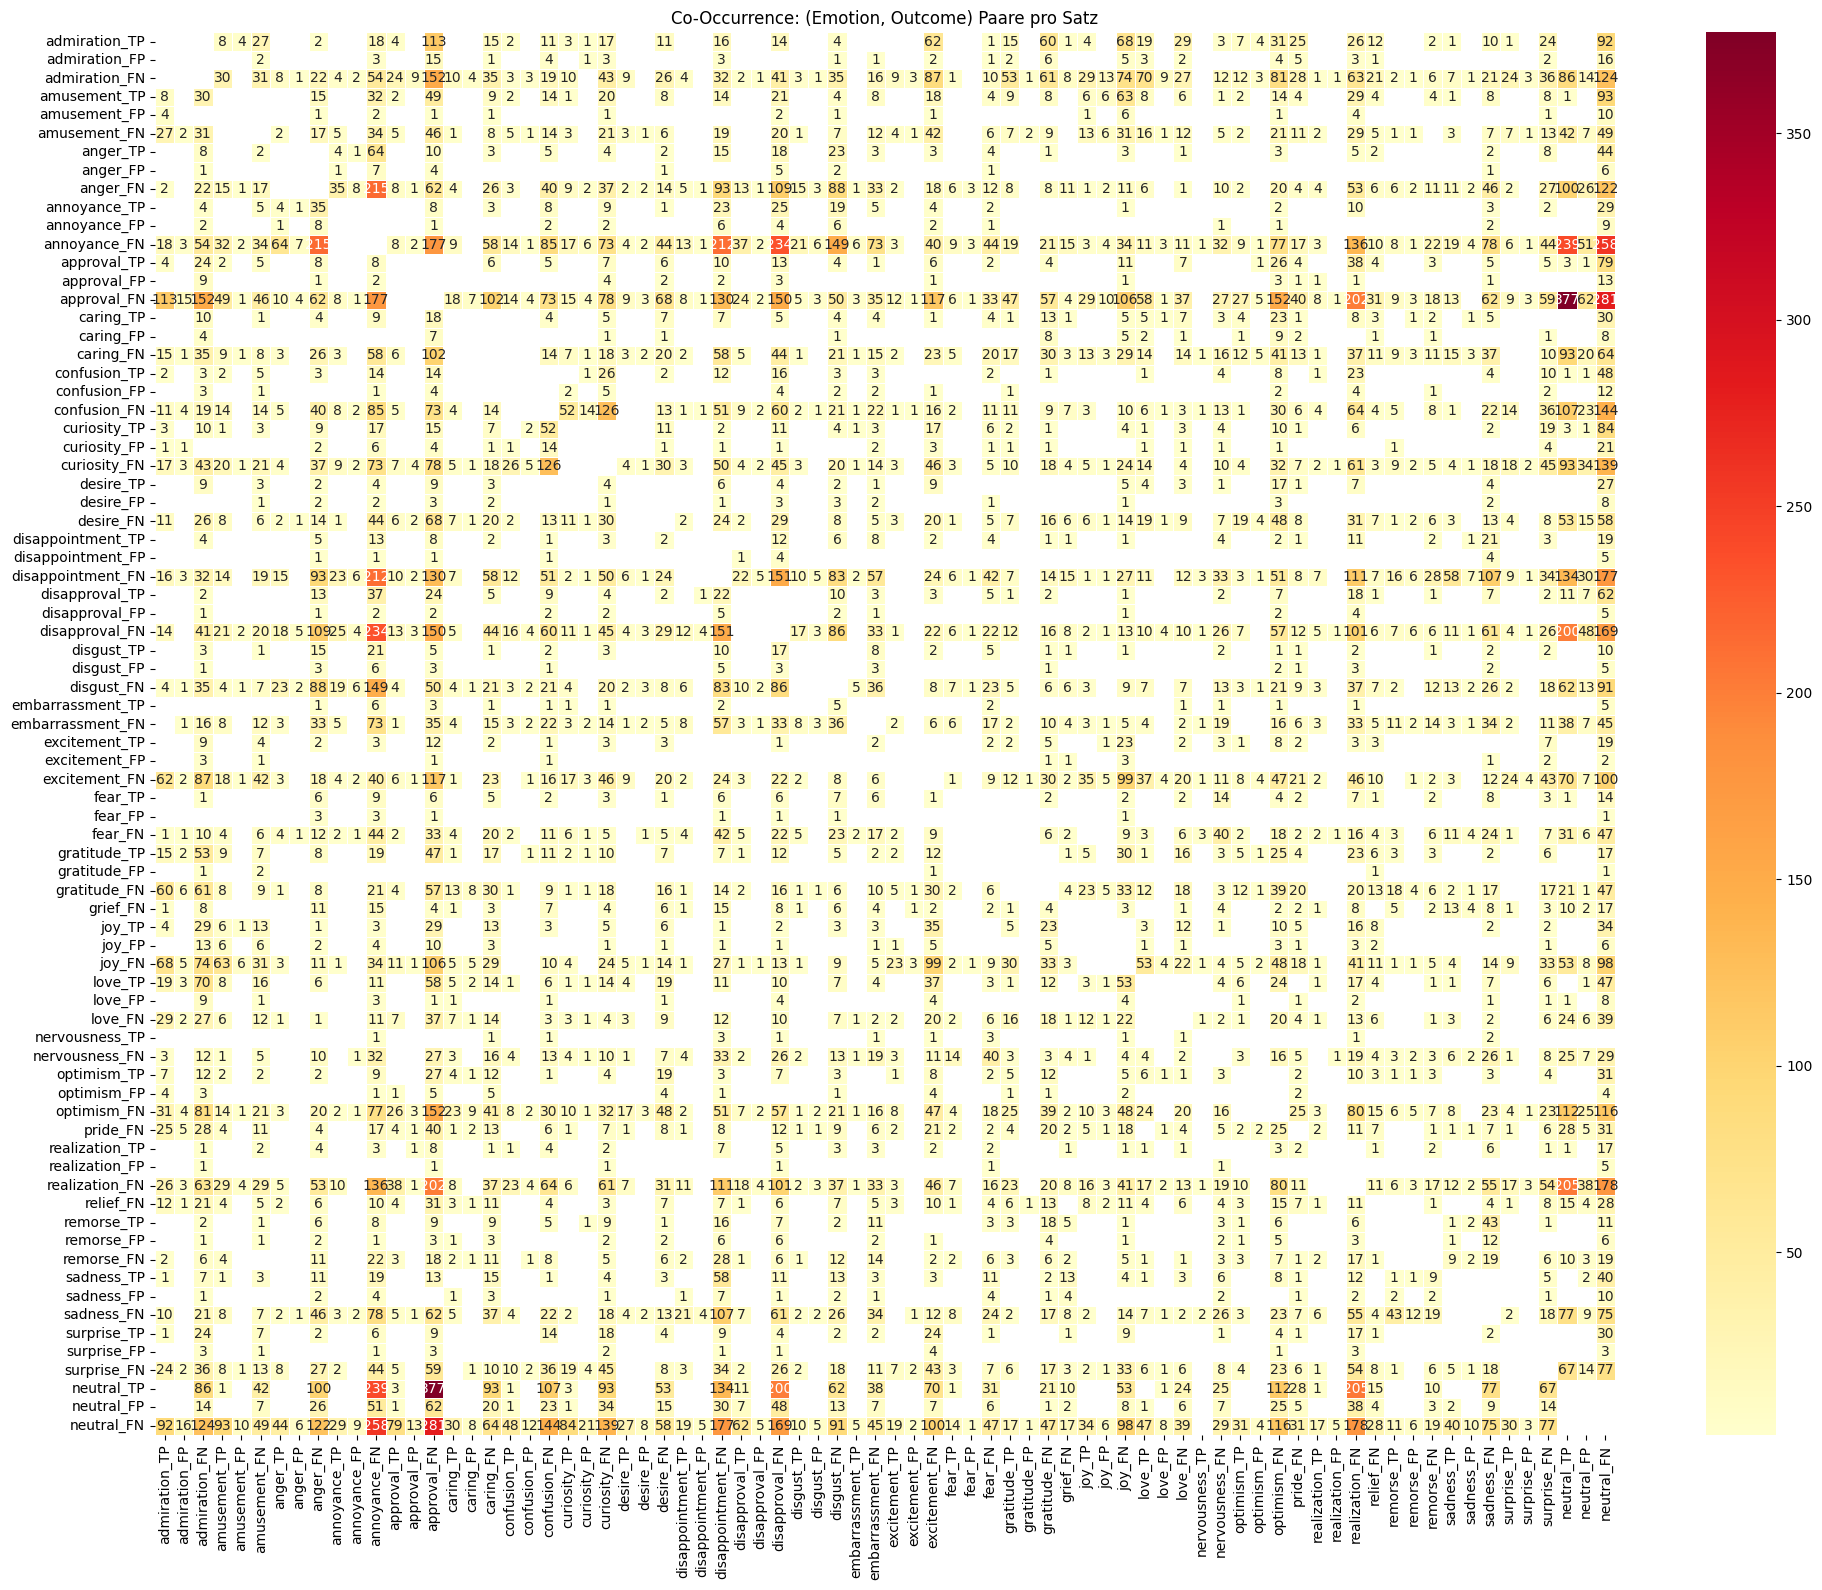

In [33]:
plt.figure(figsize=(20, 16))
cooc_masked = cooc.where(cooc > 0)
sns.heatmap(cooc_masked, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Co-Occurrence: (Emotion, Outcome) Paare pro Satz")
plt.tight_layout()
plt.show()

In [34]:
summary = pd.DataFrame([
    {
        "emotion": e,
        "TP": int(((pred_binary[e] == 1) & (test_data_fixed[e] == 1)).sum()),
        "FP": int(((pred_binary[e] == 1) & (test_data_fixed[e] == 0)).sum()),
        "FN": int(((pred_binary[e] == 0) & (test_data_fixed[e] == 1)).sum()),
        "TN": int(((pred_binary[e] == 0) & (test_data_fixed[e] == 0)).sum()),
    }
    for e in emotion_cols
]).set_index("emotion")

print(summary)

                  TP   FP    FN    TN
emotion                              
admiration       413   29   563  4768
amusement        304   18   221  5230
anger            128   11   453  5181
annoyance         84   18   945  4726
approval         161   17  1204  4391
caring            83   19   325  5346
confusion        108   18   431  5216
curiosity        168   29   456  5120
desire            58   14   234  5467
disappointment    56    9   637  5071
disapproval      137   10   680  4946
disgust           53    9   343  5368
embarrassment     18    0   201  5554
excitement        52    4   413  5304
fear              46    3   166  5558
gratitude        309    3   248  5213
grief              0    0    51  5722
joy              122   29   409  5213
love             274   16   148  5335
nervousness        5    0   138  5630
optimism         105   10   504  5154
pride              0    0   122  5651
realization       38    5   697  5033
relief             0    0   104  5669
remorse     

In [35]:
# Every Pair with count > 10
high_cooc = []

for i in range(len(cooc.index)):
    for j in range(i+1, len(cooc.columns)):  # nur oberes Dreieck, keine Duplikate
        val = cooc.iloc[i, j]
        if val > 10:
            high_cooc.append({
                "emotion_outcome_1": cooc.index[i],
                "emotion_outcome_2": cooc.columns[j],
                "count": int(val)
            })

high_cooc_df = pd.DataFrame(high_cooc).sort_values("count", ascending=False)
pd.set_option('display.max_rows', None)
print(high_cooc_df)

     emotion_outcome_1  emotion_outcome_2  count
193        approval_FN         neutral_TP    377
195        approval_FN         neutral_FN    281
155       annoyance_FN         neutral_FN    258
153       annoyance_FN         neutral_TP    239
133       annoyance_FN     disapproval_FN    234
94            anger_FN       annoyance_FN    215
131       annoyance_FN  disappointment_FN    212
450     realization_FN         neutral_TP    205
187        approval_FN     realization_FN    202
334     disapproval_FN         neutral_TP    200
452     realization_FN         neutral_FN    178
123       annoyance_FN        approval_FN    177
315  disappointment_FN         neutral_FN    177
336     disapproval_FN         neutral_FN    169
185        approval_FN        optimism_FN    152
28       admiration_FN        approval_FN    152
295  disappointment_FN     disapproval_FN    151
171        approval_FN     disapproval_FN    150
135       annoyance_FN         disgust_FN    149
251       confusion_

In [36]:
test_data_fixed.to_csv("./data/test_data_with_predictions.csv", index=False)

In [37]:
rows = []

# True emotions
true_counts = test_data_fixed[emotion_cols].sum(axis=1)
rows.append({
    "Model": "True Labels",
    "More than 1": int((true_counts > 1).sum()),
    "More than 1 (%)": f"{(true_counts > 1).mean() * 100:.1f}%",
    "More than 2": int((true_counts > 2).sum()),
    "More than 2 (%)": f"{(true_counts > 2).mean() * 100:.1f}%",
})

# Per experiment
for text_col, model_key, output_col in experiments:
    if output_col not in test_data_fixed.columns:
        continue

    pb = pd.DataFrame(0, index=test_data_fixed.index, columns=emotion_cols)
    for idx, pred in enumerate(test_data_fixed[output_col]):
        if isinstance(pred, dict):
            for emotion, val in pred.items():
                if emotion in emotion_cols and val == 1:
                    pb.loc[pb.index[idx], emotion] = 1

    pred_counts = pb.sum(axis=1)
    rows.append({
        "Model": f"{model_key} – {text_col}",
        "More than 1": int((pred_counts > 1).sum()),
        "More than 1 (%)": f"{(pred_counts > 1).mean() * 100:.1f}%",
        "More than 2": int((pred_counts > 2).sum()),
        "More than 2 (%)": f"{(pred_counts > 2).mean() * 100:.1f}%",
    })

cardinality_df = pd.DataFrame(rows).set_index("Model")
print(cardinality_df)

                                             More than 1 More than 1 (%)  \
Model                                                                      
True Labels                                         4934           85.5%   
roberta_baseline – 01_minimal_preprocessing          230            4.0%   
roberta_baseline – 02_medium_preprocessing           208            3.6%   
roberta_baseline – 03_harsh_preprocessing            127            2.2%   
bert_baseline – 01_minimal_preprocessing               0            0.0%   
bert_baseline – 02_medium_preprocessing                0            0.0%   
bert_baseline – 03_harsh_preprocessing                 0            0.0%   
ekman_baseline – 01_minimal_preprocessing              0            0.0%   
ekman_baseline – 02_medium_preprocessing               0            0.0%   
ekman_baseline – 03_harsh_preprocessing                0            0.0%   

                                             More than 2 More than 2 (%)  
Model       

FINE TUNING THE MODEL

Split the data

In [38]:
texts = train_val_data['01_minimal_preprocessing'].tolist()  # or 'text' column
labels = train_val_data[emotion_cols].values  # Already in correct format

# Split into train (80%), validation (10%), and test (10%)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, 
    test_size=0.2222, 
    random_state=42
)

print(f"Data split complete!")
print(f"Train: {len(train_texts)} samples")
print(f"Validation: {len(val_texts)} samples")

Data split complete!
Train: 3287 samples
Validation: 940 samples


In [39]:
# Best model from your baseline (BERT)
model_name = 'monologg/bert-base-cased-goemotions-original'  # Best performer
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(emotion_cols),
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [40]:
train_dataset = GoEmotionsDataset(train_texts, train_labels, tokenizer)
val_dataset = GoEmotionsDataset(val_texts, val_labels, tokenizer)


In [41]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,              
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",  
    fp16=torch.cuda.is_available(),  
    dataloader_num_workers=2,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [42]:
compute_metrics = make_metrics_function(emotion_cols, multilabel_metrics)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,  # Now this is the actual function
)

In [43]:
trainer.train()

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Weighted F1,Samples F1,Hamming Loss,Exact Match,Micro Precision,Micro Recall,Runtime,Samples Per Second,Steps Per Second
1,0.267056,0.247039,0.559535,0.481837,0.552508,0.607119,0.071960,0.141489,0.746741,0.447378,7.570000,124.174000,3.963000
2,0.212087,0.211534,0.575246,0.491014,0.558808,0.617901,0.068845,0.151064,0.778060,0.456303,7.358300,127.746000,4.077000
3,0.173774,0.205678,0.578520,0.483634,0.563432,0.618852,0.069035,0.148936,0.768804,0.463741,7.514000,125.099000,3.993000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=618, training_loss=0.2295432970361802, metrics={'train_runtime': 286.8562, 'train_samples_per_second': 34.376, 'train_steps_per_second': 2.154, 'total_flos': 2534320112292000.0, 'train_loss': 0.2295432970361802, 'epoch': 3.0})

In [44]:
#model.save_pretrained('./fine_tuned_goemotions')
#tokenizer.save_pretrained('./fine_tuned_goemotions')

In [45]:
dummy_labels = np.zeros((len(test_data_fixed), len(emotion_cols)))

test_texts_fixed = test_data_fixed['01_minimal_preprocessing'].tolist()
test_dataset_fixed = GoEmotionsDataset(test_texts_fixed, dummy_labels, tokenizer)
test_predictions = trainer.predict(test_dataset_fixed)

# Converting predictions to binary
test_probs = 1.0 / (1.0 + np.exp(-test_predictions.predictions))
test_pred_binary = (test_probs >= 0.5).astype(int)

fine_tuned_predictions = []
for i in range(len(test_pred_binary)):
    pred_dict = {emotion_cols[j]: test_pred_binary[i][j] for j in range(len(emotion_cols))}
    fine_tuned_predictions.append(pred_dict)

In [46]:
test_data_fixed['pred_finetuned_bert_text_only'] = fine_tuned_predictions
test_data_fixed['pred_finetuned_labels'] = test_data_fixed['pred_finetuned_bert_text_only'].apply(prediction_to_labels)

In [47]:
print(f"Length of test_data: {len(test_data_fixed)}")
print(f"Length of test_pred_binary: {len(test_pred_binary)}")

Length of test_data: 5773
Length of test_pred_binary: 5773


In [48]:
test_data_fixed[['true_emotions_label', 'pred_roberta_minimal_labels', 'pred_finetuned_labels']].head()

,true_emotions_label,pred_roberta_minimal_labels,pred_finetuned_labels
0,"[desire, optimism, neutral]",[neutral],[neutral]
1,"[amusement, neutral]",[joy],[amusement]
2,"[approval, disappointment, love, sadness]",[love],"[love, sadness]"
3,"[annoyance, disapproval, nervousness]",[],"[annoyance, disappointment, neutral]"
4,"[admiration, anger, annoyance, confusion, neut...",[admiration],"[admiration, anger, annoyance]"


In [49]:
y_true = test_data_fixed[emotion_cols].values
y_pred = test_pred_binary

micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
samples_f1 = f1_score(y_true, y_pred, average='samples', zero_division=0)
hl = hamming_loss(y_true, y_pred)
exact_match = (y_pred == y_true).all(axis=1).mean()

In [50]:
true_labels = test_data_fixed[emotion_cols].values

models_to_evaluate = {
    'RoBERTa (Minimal)': 'pred_roberta_minimal',
    'RoBERTa (Medium)': 'pred_roberta_medium',
    'RoBERTa (Harsh)': 'pred_roberta_harsh',
    'BERT (Minimal)': 'pred_bert_minimal',
    'BERT (Medium)': 'pred_bert_medium',
    'BERT (Harsh)': 'pred_bert_harsh',
    'Ekman (Minimal)': 'pred_ekman_minimal',
    'Ekman (Medium)': 'pred_ekman_medium',
    'Ekman (Harsh)': 'pred_ekman_harsh',
}

comparison_data = []
for model_name, pred_col in models_to_evaluate.items():
    if pred_col in test_data_fixed.columns:
        preds = test_data_fixed[pred_col].apply(
            lambda x: [x.get(emotion, 0) for emotion in emotion_cols]
        )
        pred_array = np.array([list(p) for p in preds])
        
        comparison_data.append({
            'model': model_name,
            'micro_f1': f1_score(true_labels, pred_array, average='micro', zero_division=0),
            'macro_f1': f1_score(true_labels, pred_array, average='macro', zero_division=0),
            'weighted_f1': f1_score(true_labels, pred_array, average='weighted', zero_division=0),
            'samples_f1': f1_score(true_labels, pred_array, average='samples', zero_division=0),
            'hamming_loss': hamming_loss(true_labels, pred_array),
            'exact_match_ratio': (pred_array == true_labels).all(axis=1).mean()
        })

fine_tuned_results = pd.DataFrame([{
    'model': 'Fine-tuned BERT (Text Only)',
    'micro_f1': micro_f1,
    'macro_f1': macro_f1,
    'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    'samples_f1': samples_f1,
    'hamming_loss': hl,
    'exact_match_ratio': exact_match
}])

comparison_df_updated = pd.DataFrame(comparison_data)
comparison_df_updated = pd.concat([comparison_df_updated, fine_tuned_results], ignore_index=True)

comparison_df_updated = comparison_df_updated.sort_values('weighted_f1', ascending=False)

comparison_df_updated.to_csv('model_comparison_complete.csv', index=False)

# Highlight the best model
best_model = comparison_df_updated.iloc[0]
print(f"\n BEST MODEL: {best_model['model']}")
print(f"   Weighted F1: {best_model['weighted_f1']:.4f}")


 BEST MODEL: Fine-tuned BERT (Text Only)
   Weighted F1: 0.5722


In [51]:
prediction_cols_updated = prediction_cols.copy()  # Start with existing models
prediction_cols_updated['Fine-tuned BERT (Text Only)'] = 'pred_finetuned_bert_text_only'

In [52]:
comparison_df_updated

,model,micro_f1,macro_f1,weighted_f1,samples_f1,hamming_loss,exact_match_ratio
9,Fine-tuned BERT (Text Only),0.587234,0.492406,0.572155,0.629020,0.067810,0.165772
3,BERT (Minimal),0.481666,0.385466,0.462367,0.549782,0.071274,0.137017
4,BERT (Medium),0.463417,0.360929,0.438331,0.528022,0.073680,0.133380
0,RoBERTa (Minimal),0.430106,0.325020,0.396434,0.479596,0.076495,0.135805
1,RoBERTa (Medium),0.416624,0.308876,0.379229,0.463694,0.077893,0.132340
5,BERT (Harsh),0.411230,0.263749,0.347466,0.470566,0.080956,0.121947
2,RoBERTa (Harsh),0.388304,0.246649,0.324832,0.437383,0.082311,0.123333
7,Ekman (Medium),0.099601,0.055655,0.041759,0.092783,0.122702,0.007968
6,Ekman (Minimal),0.098689,0.053839,0.040489,0.091459,0.122943,0.007622
8,Ekman (Harsh),0.093945,0.053147,0.039740,0.087893,0.123030,0.008315


In [53]:
# Save to CSV
comparison_df_updated.to_csv('model_comparison_with_finetuned.csv', index=False)

VADER APPROACH

In [54]:
analyzer = SentimentIntensityAnalyzer()

In [55]:
test_data_fixed = add_vader_features(test_data_fixed, '01_minimal_preprocessing')

In [56]:
test_data_fixed = apply_vader_correction(test_data_fixed, 'pred_roberta_minimal', 'pred_roberta_vader_corrected')

Applied 166 corrections


In [57]:
# Evaluate original vs corrected
original_metrics = evaluate_predictions(test_data_fixed, 'pred_roberta_minimal', emotion_cols)
corrected_metrics = evaluate_predictions(test_data_fixed, 'pred_roberta_vader_corrected', emotion_cols)

# Create comparison DataFrame
comparison = pd.DataFrame([original_metrics, corrected_metrics], index=['Original', 'VADER-Corrected'])
print("=" * 50)
print("VADER Correction Results")
print("=" * 50)
print(comparison.round(4))

# Calculate change
weighted_f1_change = (corrected_metrics['weighted_f1'] - original_metrics['weighted_f1']) * 100
print(f"\weighted F1 Change: {weighted_f1_change:+.2f}%")

<>:14: SyntaxWarning: invalid escape sequence '\w'
<>:14: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_923/536364292.py:14: SyntaxWarning: invalid escape sequence '\w'
  print(f"\weighted F1 Change: {weighted_f1_change:+.2f}%")


VADER Correction Results
                 micro_f1  macro_f1  weighted_f1  samples_f1  hamming_loss  \
Original           0.4301    0.3250       0.3964      0.4796        0.0765   
VADER-Corrected    0.4197    0.3129       0.3851      0.4660        0.0773   

                 exact_match_ratio  
Original                    0.1358  
VADER-Corrected             0.1336  
\weighted F1 Change: -1.14%


In [58]:
# Count actual changes
changes = sum(
    test_data_fixed['pred_roberta_minimal'].iloc[i] != test_data_fixed['pred_roberta_vader_corrected'].iloc[i]
    for i in range(len(test_data_fixed))
)
print(f"Predictions changed: {changes} / {len(test_data_fixed)}")

# VADER score distribution
print(f"\n|compound| > 0.3: {(abs(test_data_fixed['vader_compound']) > 0.3).sum()}")
print(f"Sentiment distribution:")
print(test_data_fixed['vader_sentiment'].value_counts())

Predictions changed: 166 / 5773

|compound| > 0.3: 3540
Sentiment distribution:
vader_sentiment
positive    2780
negative    1741
neutral     1252
Name: count, dtype: int64


In [59]:
# At the end of your Colab session, DOWNLOAD results to local

# Download CSV files
from google.colab import files

# Download model comparison results
files.download('model_comparison_complete.csv')
files.download('model_comparison_with_finetuned.csv')

# Download predictions if needed
test_data_fixed[['text', 'true_emotions_label', 
                 'pred_roberta_minimal_labels', 
                 'pred_finetuned_labels']].to_csv('predictions_sample.csv', index=False)
files.download('predictions_sample.csv')

# Download metrics
comparison_df_updated.to_csv('model_metrics.csv', index=False)
files.download('model_metrics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>